In [1]:
# # Install pinned dependencies (run once)
# %pip install -r ../requirements.txt


# MNIST MLP Baseline
Train a simple MLP on MNIST and track:
- train loss
- train accuracy
- validation loss
- validation accuracy
- epoch time
- number of parameters


In [2]:
import time
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [3]:
# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

val_size = 10000
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(seed))

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

len(train_set), len(val_set), len(test_set)


(50000, 10000, 10000)

In [4]:
# Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of trainable parameters: {num_params:,}')


Number of trainable parameters: 235,146


In [5]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'epoch_time_sec': [],
}

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits  = model(x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [6]:
# Train loop
for epoch in range(1, epochs + 1):
    start = time.perf_counter()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    elapsed = time.perf_counter() - start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epoch_time_sec'].append(elapsed)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.2f}s"
    )


Epoch 01/10 | train_loss=0.3422 train_acc=0.8969 | val_loss=0.1573 val_acc=0.9520 | time=2.35s
Epoch 02/10 | train_loss=0.1478 train_acc=0.9551 | val_loss=0.1108 val_acc=0.9660 | time=2.33s
Epoch 03/10 | train_loss=0.1064 train_acc=0.9675 | val_loss=0.0950 val_acc=0.9705 | time=2.23s
Epoch 04/10 | train_loss=0.0889 train_acc=0.9722 | val_loss=0.0945 val_acc=0.9697 | time=2.18s
Epoch 05/10 | train_loss=0.0739 train_acc=0.9764 | val_loss=0.0930 val_acc=0.9730 | time=2.17s
Epoch 06/10 | train_loss=0.0636 train_acc=0.9802 | val_loss=0.0951 val_acc=0.9700 | time=2.08s
Epoch 07/10 | train_loss=0.0557 train_acc=0.9819 | val_loss=0.0848 val_acc=0.9751 | time=2.18s
Epoch 08/10 | train_loss=0.0499 train_acc=0.9837 | val_loss=0.0785 val_acc=0.9779 | time=2.14s
Epoch 09/10 | train_loss=0.0460 train_acc=0.9845 | val_loss=0.0860 val_acc=0.9745 | time=2.15s
Epoch 10/10 | train_loss=0.0430 train_acc=0.9861 | val_loss=0.0819 val_acc=0.9755 | time=2.17s


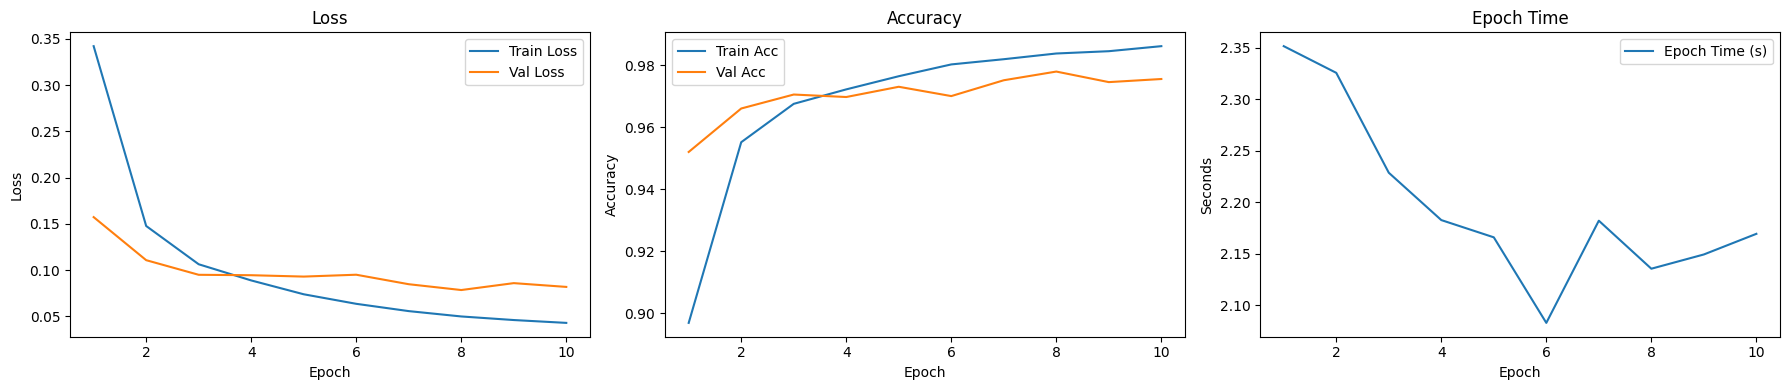

In [7]:
# Plot tracked metrics
epochs_axis = range(1, epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs_axis, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_axis, history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_axis, history['train_acc'], label='Train Acc')
axes[1].plot(epochs_axis, history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(epochs_axis, history['epoch_time_sec'], label='Epoch Time (s)')
axes[2].set_title('Epoch Time')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Seconds')
axes[2].legend()

plt.tight_layout()
plt.show()


In [8]:
# Optional: evaluate on test set
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)
print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}')


Test loss: 0.0669 | Test accuracy: 0.9795


# Simple Corr weights collection criterion

In [9]:
import time
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [10]:
device

device(type='cuda')

In [11]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x, return_activations=False, masks=None):
        """
        masks:
            optional dict:
            {
                "a1": tensor of shape [256], 1 = keep, 0 = ablate
                "a2": tensor of shape [128], 1 = keep, 0 = ablate
            }
        """
        masks = masks or {}
        activations = {}

        x = self.flatten(x)

        z1 = self.fc1(x)
        a1 = self.relu1(z1)

        if "a1" in masks:
            mask = masks["a1"].to(a1.device).view(1, -1)
            a1 = a1 * mask

        d1 = self.drop1(a1)

        z2 = self.fc2(d1)
        a2 = self.relu2(z2)

        if "a2" in masks:
            mask = masks["a2"].to(a2.device).view(1, -1)
            a2 = a2 * mask

        d2 = self.drop2(a2)

        logits = self.fc3(d2)

        if return_activations:
            activations = {
                "a1": a1,
                "a2": a2,
                "logits": logits,
            }
            return logits, activations

        return logits

In [12]:
# model = MLP().to(device)
# num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Number of trainable parameters: {num_params:,}')

In [13]:
class ActivationStatsCollector:
    def __init__(self, layer_dims, num_classes, device):
        self.layer_dims = layer_dims
        self.num_classes = num_classes
        self.device = device

        self.n_seen = 0

        self.activation_sum = {}
        self.activation_sq_sum = {}
        self.firing_sum = {}
        self.coactivation_sum = {}
        self.class_firing_sum = {}

        for layer, dim in layer_dims.items():
            self.activation_sum[layer] = torch.zeros(dim, device=device)
            self.activation_sq_sum[layer] = torch.zeros(dim, device=device)
            self.firing_sum[layer] = torch.zeros(dim, device=device)
            self.coactivation_sum[layer] = torch.zeros(dim, dim, device=device)
            self.class_firing_sum[layer] = torch.zeros(num_classes, dim, device=device)

        self.class_counts = torch.zeros(num_classes, device=device)

        self.logit_margins = []
        self.max_probs = []
        self.correct_flags = []

    @torch.no_grad()
    def update(self, activations, logits, y):
        batch_size = y.size(0)
        self.n_seen += batch_size

        y = y.detach()
        one_hot = F.one_hot(y, num_classes=self.num_classes).float()
        self.class_counts += one_hot.sum(dim=0)

        for layer in self.layer_dims:
            a = activations[layer].detach()
            b = (a > 0).float()

            self.activation_sum[layer] += a.sum(dim=0)
            self.activation_sq_sum[layer] += (a ** 2).sum(dim=0)
            self.firing_sum[layer] += b.sum(dim=0)
            self.coactivation_sum[layer] += b.T @ b

            self.class_firing_sum[layer] += one_hot.T @ b

        probs = F.softmax(logits.detach(), dim=1)
        max_probs, preds = probs.max(dim=1)

        top2_logits = logits.detach().topk(k=2, dim=1).values
        margins = top2_logits[:, 0] - top2_logits[:, 1]

        correct = preds.eq(y)

        self.logit_margins.append(margins.cpu())
        self.max_probs.append(max_probs.cpu())
        self.correct_flags.append(correct.cpu())

    def finalize(self):
        eps = 1e-8
        stats = {
            "n_seen": self.n_seen,
            "class_counts": self.class_counts.detach().cpu(),
        }

        for layer in self.layer_dims:
            n = max(self.n_seen, 1)

            mean_activation = self.activation_sum[layer] / n
            mean_sq_activation = self.activation_sq_sum[layer] / n
            std_activation = torch.sqrt(torch.clamp(mean_sq_activation - mean_activation ** 2, min=0.0))

            firing_rate = self.firing_sum[layer] / n
            coactivation = self.coactivation_sum[layer] / n

            # Binary activation correlation:
            # corr(i,j) = cov(b_i,b_j) / sqrt(var_i * var_j)
            p = firing_rate
            covariance = coactivation - torch.outer(p, p)
            variance = p * (1.0 - p)
            denom = torch.sqrt(torch.outer(variance, variance)).clamp_min(eps)
            correlation = covariance / denom

            # cleaner diagonal
            correlation.fill_diagonal_(1.0)

            class_counts_safe = self.class_counts.clamp_min(1.0).view(-1, 1)
            class_firing_rate = self.class_firing_sum[layer] / class_counts_safe

            class_selectivity = (
                class_firing_rate.max(dim=0).values
                - class_firing_rate.mean(dim=0)
            )

            stats[f"{layer}_mean_activation"] = mean_activation.detach().cpu()
            stats[f"{layer}_std_activation"] = std_activation.detach().cpu()
            stats[f"{layer}_firing_rate"] = firing_rate.detach().cpu()
            stats[f"{layer}_coactivation"] = coactivation.detach().cpu()
            stats[f"{layer}_correlation"] = correlation.detach().cpu()
            stats[f"{layer}_class_firing_rate"] = class_firing_rate.detach().cpu()
            stats[f"{layer}_class_selectivity"] = class_selectivity.detach().cpu()

        if len(self.logit_margins) > 0:
            stats["logit_margins"] = torch.cat(self.logit_margins)
            stats["max_probs"] = torch.cat(self.max_probs)
            stats["correct_flags"] = torch.cat(self.correct_flags)
        else:
            stats["logit_margins"] = torch.empty(0)
            stats["max_probs"] = torch.empty(0)
            stats["correct_flags"] = torch.empty(0, dtype=torch.bool)

        return stats

In [14]:
def enrich_stats_with_model_weights(stats, model):
    """
    Adds:
    - outgoing weight norm
    - simple importance score
    - redundancy score
    - Hebbian-style pruning score

    Lower hebbian_prune_score = better prune candidate.
    """

    with torch.no_grad():
        # fc1 neuron i feeds into column i of fc2.weight
        a1_outgoing_norm = model.fc2.weight.detach().cpu().norm(p=2, dim=0)

        # fc2 neuron i feeds into column i of fc3.weight
        a2_outgoing_norm = model.fc3.weight.detach().cpu().norm(p=2, dim=0)

    for layer, outgoing_norm in {
        "a1": a1_outgoing_norm,
        "a2": a2_outgoing_norm,
    }.items():
        mean_activation = stats[f"{layer}_mean_activation"]
        firing_rate = stats[f"{layer}_firing_rate"]
        correlation = stats[f"{layer}_correlation"].clone()

        dim = correlation.size(0)

        # remove diagonal from redundancy calculation
        correlation.fill_diagonal_(0.0)

        redundancy_mean_abs = correlation.abs().sum(dim=1) / max(dim - 1, 1)
        redundancy_max_abs = correlation.abs().max(dim=1).values

        importance = mean_activation * firing_rate * outgoing_norm

        # Lower score = weak + redundant => prune candidate
        hebbian_prune_score = importance / (1.0 + redundancy_max_abs)

        stats[f"{layer}_outgoing_weight_norm"] = outgoing_norm
        stats[f"{layer}_importance"] = importance
        stats[f"{layer}_redundancy_mean_abs_corr"] = redundancy_mean_abs
        stats[f"{layer}_redundancy_max_abs_corr"] = redundancy_max_abs
        stats[f"{layer}_hebbian_prune_score"] = hebbian_prune_score

    return stats

In [15]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    collect_stats=False,
    num_classes=10,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    collector = None

    if collect_stats:
        collector = ActivationStatsCollector(
            layer_dims={"a1": 256, "a2": 128},
            num_classes=num_classes,
            device=device,
        )

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if collect_stats:
                logits, activations = model(x, return_activations=True)
                collector.update(activations, logits, y)
            else:
                logits = model(x)

            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * x.size(0)

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    if collect_stats:
        return epoch_loss, epoch_acc, collector.finalize()

    return epoch_loss, epoch_acc

In [16]:
model = MLP().to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time_sec": [],

    "train_activation_stats": [],
    "val_activation_stats": [],
}

Number of trainable parameters: 235,146


In [17]:
for epoch in range(1, epochs + 1):
    start = time.perf_counter()

    train_loss, train_acc, train_stats = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        collect_stats=True,
        num_classes=10,
    )

    val_loss, val_acc, val_stats = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        collect_stats=True,
        num_classes=10,
    )

    train_stats = enrich_stats_with_model_weights(train_stats, model)
    val_stats = enrich_stats_with_model_weights(val_stats, model)

    elapsed = time.perf_counter() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["epoch_time_sec"].append(elapsed)

    history["train_activation_stats"].append(train_stats)
    history["val_activation_stats"].append(val_stats)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.2f}s"
    )

Epoch 01/10 | train_loss=0.3413 train_acc=0.8973 | val_loss=0.1554 val_acc=0.9533 | time=2.32s
Epoch 02/10 | train_loss=0.1429 train_acc=0.9563 | val_loss=0.1135 val_acc=0.9674 | time=2.22s
Epoch 03/10 | train_loss=0.1065 train_acc=0.9669 | val_loss=0.1018 val_acc=0.9699 | time=2.23s
Epoch 04/10 | train_loss=0.0851 train_acc=0.9738 | val_loss=0.0880 val_acc=0.9731 | time=2.24s
Epoch 05/10 | train_loss=0.0715 train_acc=0.9775 | val_loss=0.0854 val_acc=0.9735 | time=2.33s
Epoch 06/10 | train_loss=0.0644 train_acc=0.9790 | val_loss=0.0784 val_acc=0.9775 | time=2.36s
Epoch 07/10 | train_loss=0.0572 train_acc=0.9814 | val_loss=0.0878 val_acc=0.9756 | time=2.25s
Epoch 08/10 | train_loss=0.0511 train_acc=0.9833 | val_loss=0.0783 val_acc=0.9772 | time=2.27s
Epoch 09/10 | train_loss=0.0455 train_acc=0.9852 | val_loss=0.0846 val_acc=0.9769 | time=2.41s
Epoch 10/10 | train_loss=0.0431 train_acc=0.9856 | val_loss=0.0741 val_acc=0.9790 | time=2.41s


In [18]:
def plot_training_history(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_range, history["train_loss"], label="train loss")
    plt.plot(epochs_range, history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_range, history["train_acc"], label="train acc")
    plt.plot(epochs_range, history["val_acc"], label="val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_range, history["epoch_time_sec"], label="epoch time")
    plt.xlabel("Epoch")
    plt.ylabel("Seconds")
    plt.title("Epoch time")
    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
def plot_activation_scatter(stats, layer):
    mean_activation = stats[f"{layer}_mean_activation"]
    firing_rate = stats[f"{layer}_firing_rate"]
    importance = stats[f"{layer}_importance"]

    plt.figure(figsize=(6, 5))
    plt.scatter(
        firing_rate.numpy(),
        mean_activation.numpy(),
        s=20 + 300 * importance.numpy() / (importance.max().item() + 1e-8),
        alpha=0.7,
    )
    plt.xlabel("Firing rate")
    plt.ylabel("Mean activation")
    plt.title(f"{layer}: firing rate vs mean activation")
    plt.grid(True)
    plt.show()

In [20]:
def plot_correlation_heatmap(stats, layer):
    corr = stats[f"{layer}_correlation"]

    plt.figure(figsize=(6, 5))
    plt.imshow(corr.numpy(), aspect="auto", vmin=-1, vmax=1)
    plt.colorbar(label="Binary activation correlation")
    plt.xlabel("Neuron")
    plt.ylabel("Neuron")
    plt.title(f"{layer}: activation correlation heatmap")
    plt.show()

In [21]:
def plot_importance_vs_redundancy(stats, layer):
    importance = stats[f"{layer}_importance"]
    redundancy = stats[f"{layer}_redundancy_max_abs_corr"]
    prune_score = stats[f"{layer}_hebbian_prune_score"]

    plt.figure(figsize=(6, 5))
    plt.scatter(
        importance.numpy(),
        redundancy.numpy(),
        c=prune_score.numpy(),
        alpha=0.75,
    )
    plt.colorbar(label="Hebbian prune score; lower = more prunable")
    plt.xlabel("Importance = mean_activation × firing_rate × outgoing_norm")
    plt.ylabel("Max abs correlation with another neuron")
    plt.title(f"{layer}: importance vs redundancy")
    plt.grid(True)
    plt.show()

In [22]:
def plot_class_firing_heatmap(stats, layer):
    class_firing = stats[f"{layer}_class_firing_rate"]

    plt.figure(figsize=(9, 4))
    plt.imshow(class_firing.numpy(), aspect="auto")
    plt.colorbar(label="P(neuron active | class)")
    plt.xlabel("Neuron")
    plt.ylabel("Class")
    plt.title(f"{layer}: class-conditional firing rate")
    plt.show()

In [23]:
def plot_logit_diagnostics(stats):
    margins = stats["logit_margins"]
    max_probs = stats["max_probs"]
    correct = stats["correct_flags"].bool()

    plt.figure(figsize=(7, 4))
    plt.hist(margins.numpy(), bins=50, alpha=0.8)
    plt.xlabel("top1 logit - top2 logit")
    plt.ylabel("Count")
    plt.title("Logit margin distribution")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(max_probs[correct].numpy(), bins=50, alpha=0.6, label="correct")
    plt.hist(max_probs[~correct].numpy(), bins=50, alpha=0.6, label="incorrect")
    plt.xlabel("Max softmax probability")
    plt.ylabel("Count")
    plt.title("Confidence: correct vs incorrect")
    plt.legend()
    plt.grid(True)
    plt.show()

In [24]:
def simple_rank(x):
    """
    Approximate rank transform.
    Good enough here; tie handling is not exact.
    """
    return torch.argsort(torch.argsort(x)).float()


def spearman_corr(x, y):
    rx = simple_rank(x)
    ry = simple_rank(y)

    rx = rx - rx.mean()
    ry = ry - ry.mean()

    denom = torch.sqrt((rx ** 2).sum() * (ry ** 2).sum()).clamp_min(1e-8)
    return ((rx * ry).sum() / denom).item()


def bottom_k_set(score, ratio):
    k = max(1, int(len(score) * ratio))
    ids = torch.argsort(score)[:k]
    return set(ids.tolist())


def jaccard(a, b):
    if len(a) == 0 and len(b) == 0:
        return 1.0
    return len(a & b) / max(len(a | b), 1)

In [25]:
def plot_epoch_stability(history, layer, stat_source="val_activation_stats", ratio=0.10):
    """
    Uses hebbian_prune_score:
        lower = more prunable
    """
    all_stats = history[stat_source]
    key = f"{layer}_hebbian_prune_score"

    spearmans = []
    jaccards = []

    for i in range(len(all_stats) - 1):
        s1 = all_stats[i][key]
        s2 = all_stats[i + 1][key]

        spearmans.append(spearman_corr(s1, s2))

        b1 = bottom_k_set(s1, ratio)
        b2 = bottom_k_set(s2, ratio)
        jaccards.append(jaccard(b1, b2))

    x = range(1, len(all_stats))

    plt.figure(figsize=(7, 4))
    plt.plot(x, spearmans, marker="o")
    plt.xlabel("Epoch transition")
    plt.ylabel("Spearman rank corr")
    plt.title(f"{layer}: prune-score rank stability")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(x, jaccards, marker="o")
    plt.xlabel("Epoch transition")
    plt.ylabel(f"Jaccard overlap of bottom {int(ratio * 100)}%")
    plt.title(f"{layer}: prune-candidate set stability")
    plt.grid(True)
    plt.show()

In [26]:
@torch.no_grad()
def evaluate_with_masks(model, loader, criterion, masks=None):
    was_training = model.training
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x, masks=masks)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    model.train(was_training)

    return running_loss / total, correct / total

In [27]:
def ablation_sensitivity_curve(
    model,
    loader,
    criterion,
    stats,
    layer,
    score_key=None,
    ratios=(0.0, 0.05, 0.10, 0.20, 0.30, 0.50),
    random_trials=3,
):
    """
    layer:
        "a1" or "a2"

    score_key:
        default = f"{layer}_hebbian_prune_score"
        lower score => ablate first
    """
    if score_key is None:
        score_key = f"{layer}_hebbian_prune_score"

    score = stats[score_key]
    dim = len(score)

    ordered_ids = torch.argsort(score)

    results = {
        "ratios": [],
        "criterion_acc": [],
        "random_acc_mean": [],
        "random_acc_std": [],
    }

    for ratio in ratios:
        k = int(dim * ratio)

        # criterion-based ablation
        mask = torch.ones(dim)

        if k > 0:
            prune_ids = ordered_ids[:k]
            mask[prune_ids] = 0.0

        masks = {layer: mask}
        _, acc = evaluate_with_masks(model, loader, criterion, masks=masks)

        # random baseline
        random_accs = []

        for _ in range(random_trials):
            random_mask = torch.ones(dim)

            if k > 0:
                random_ids = torch.randperm(dim)[:k]
                random_mask[random_ids] = 0.0

            _, random_acc = evaluate_with_masks(
                model,
                loader,
                criterion,
                masks={layer: random_mask},
            )
            random_accs.append(random_acc)

        results["ratios"].append(ratio)
        results["criterion_acc"].append(acc)
        results["random_acc_mean"].append(float(np.mean(random_accs)))
        results["random_acc_std"].append(float(np.std(random_accs)))

    return results

In [28]:
def plot_ablation_curve(results, title):
    ratios = np.array(results["ratios"]) * 100
    criterion_acc = np.array(results["criterion_acc"])
    random_mean = np.array(results["random_acc_mean"])
    random_std = np.array(results["random_acc_std"])

    plt.figure(figsize=(7, 4))

    plt.plot(ratios, criterion_acc, marker="o", label="criterion ablation")
    plt.plot(ratios, random_mean, marker="o", label="random ablation")
    plt.fill_between(
        ratios,
        random_mean - random_std,
        random_mean + random_std,
        alpha=0.2,
    )

    plt.xlabel("% neurons ablated")
    plt.ylabel("Validation accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

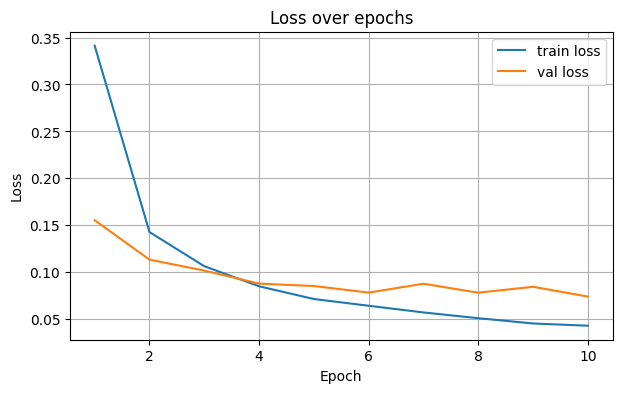

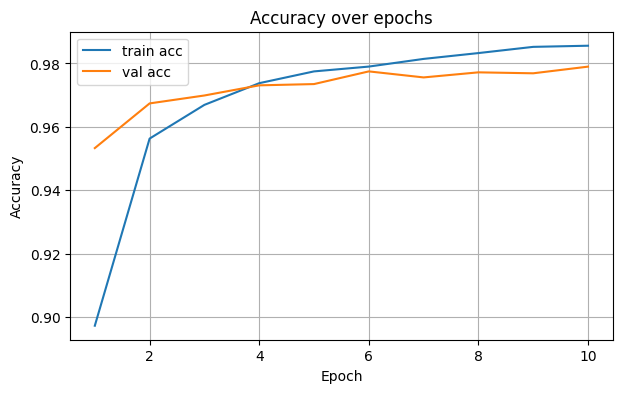

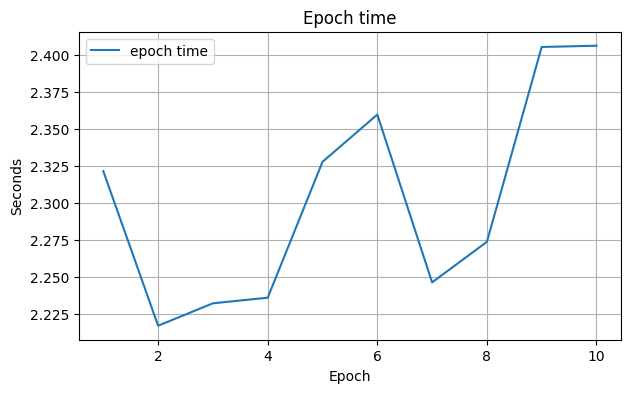

In [29]:
plot_training_history(history)

last_val_stats = history["val_activation_stats"][-1]

In [30]:
def plot_sorted_utilization(stats, layer):
    """
    Plots sorted mean activation and sorted firing rate for one layer.

    layer: "a1" or "a2"
    """

    mean_activation = stats[f"{layer}_mean_activation"]
    firing_rate = stats[f"{layer}_firing_rate"]

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(mean_activation).values.numpy())
    plt.xlabel("Neuron rank")
    plt.ylabel("Mean activation")
    plt.title(f"{layer}: sorted mean activation")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(firing_rate).values.numpy())
    plt.xlabel("Neuron rank")
    plt.ylabel("Firing rate")
    plt.title(f"{layer}: sorted firing rate")
    plt.grid(True)
    plt.show()

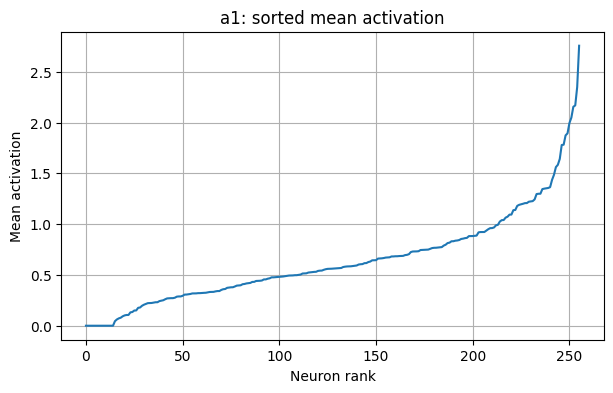

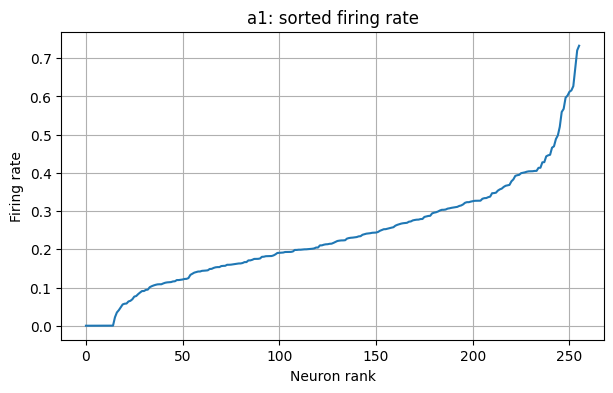

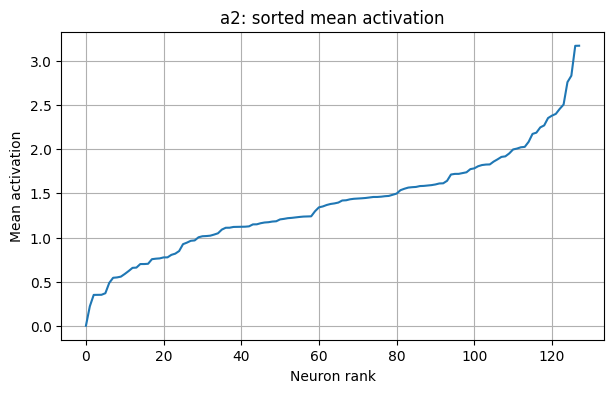

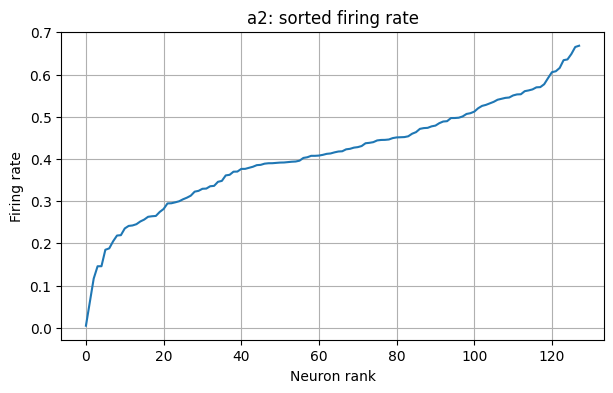

In [31]:
last_val_stats = history["val_activation_stats"][-1]

plot_sorted_utilization(last_val_stats, layer="a1")
plot_sorted_utilization(last_val_stats, layer="a2")

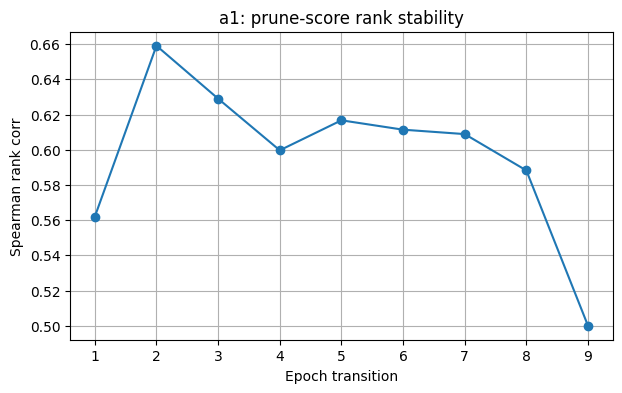

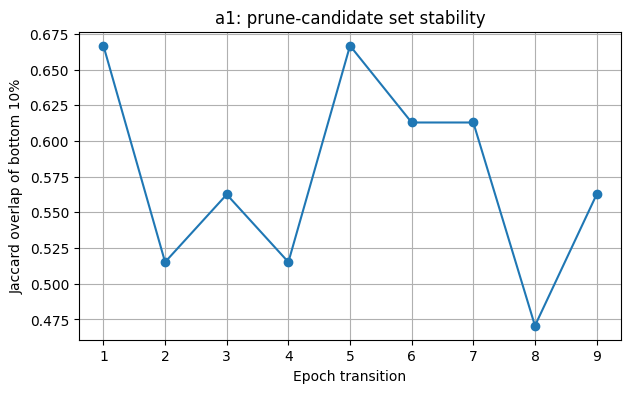

In [32]:
plot_epoch_stability(history, layer="a1", ratio=0.10)

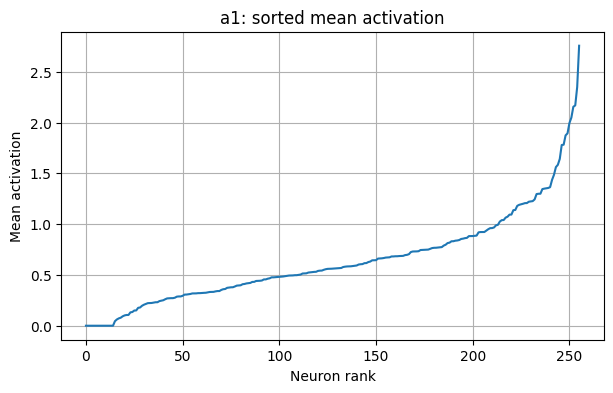

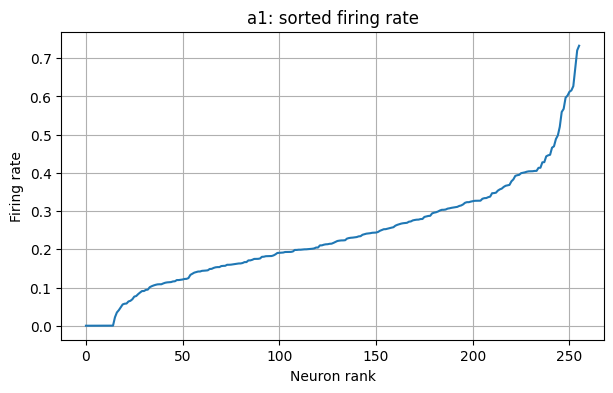

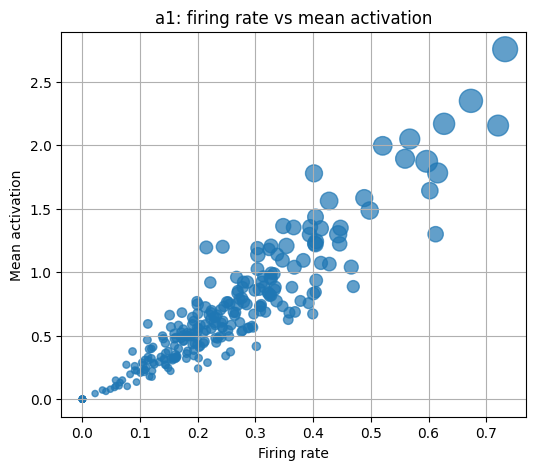

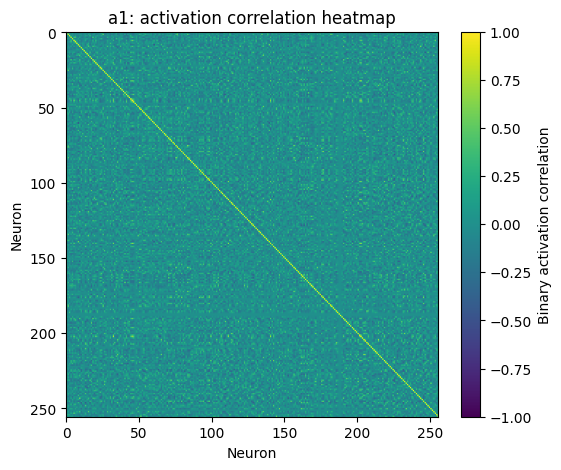

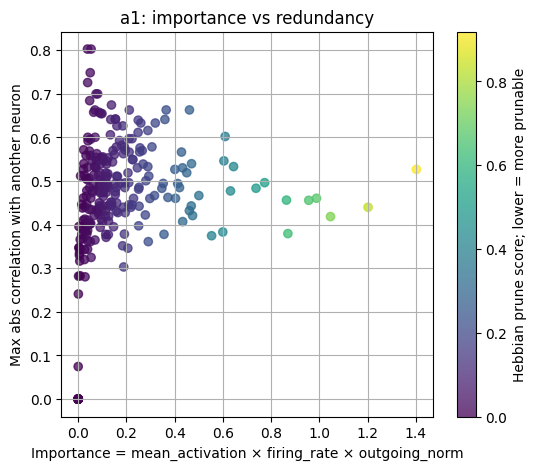

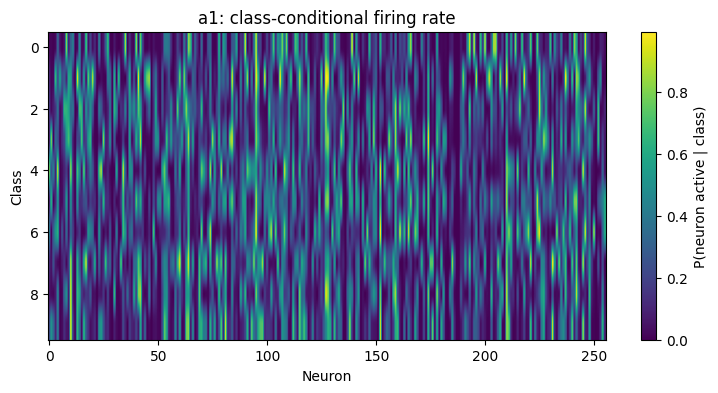

NameError: name 'plot_class_selectivity' is not defined

In [33]:
plot_sorted_utilization(last_val_stats, layer="a1")
plot_activation_scatter(last_val_stats, layer="a1")
plot_correlation_heatmap(last_val_stats, layer="a1")
plot_importance_vs_redundancy(last_val_stats, layer="a1")
plot_class_firing_heatmap(last_val_stats, layer="a1")
plot_class_selectivity(last_val_stats, layer="a1")
plot_epoch_stability(history, layer="a1", ratio=0.10)

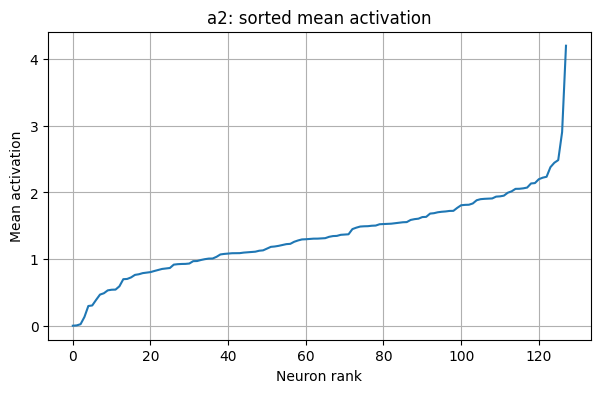

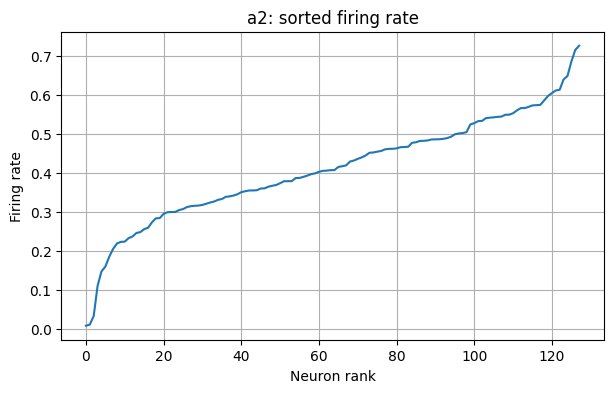

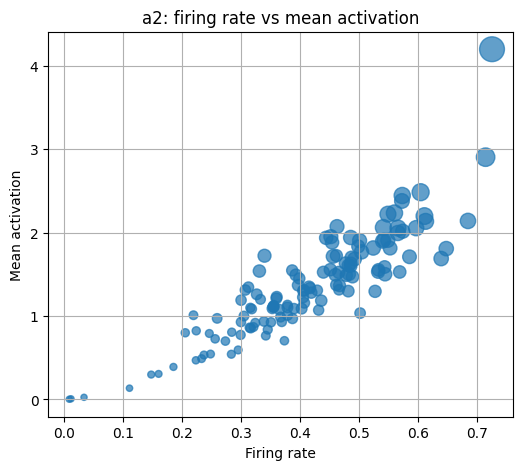

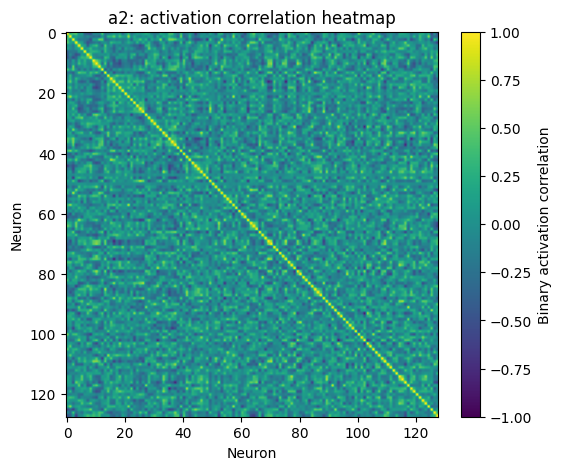

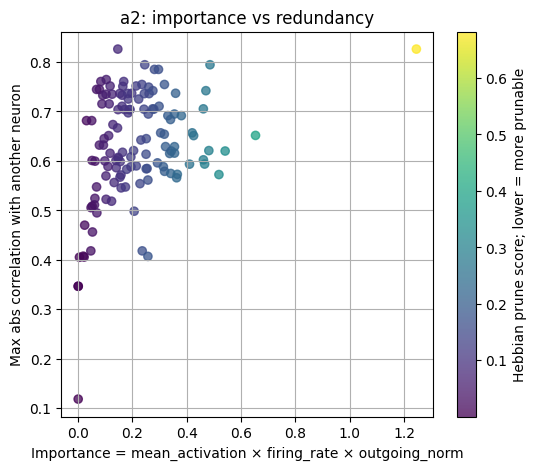

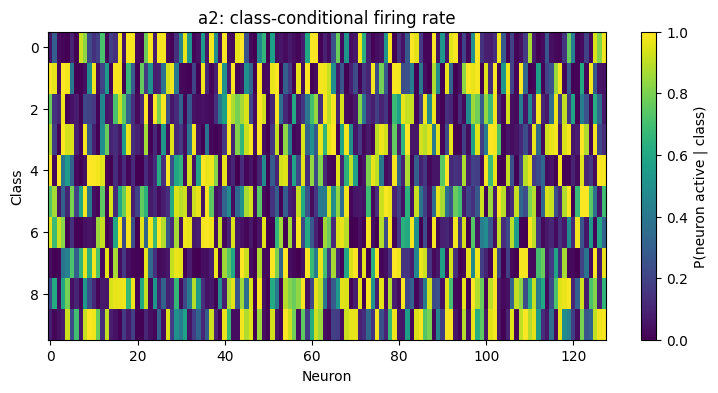

NameError: name 'plot_class_selectivity' is not defined

In [ ]:
plot_sorted_utilization(last_val_stats, layer="a2")
plot_activation_scatter(last_val_stats, layer="a2")
plot_correlation_heatmap(last_val_stats, layer="a2")
plot_importance_vs_redundancy(last_val_stats, layer="a2")
plot_class_firing_heatmap(last_val_stats, layer="a2")
plot_class_selectivity(last_val_stats, layer="a2")
plot_epoch_stability(history, layer="a2", ratio=0.10)

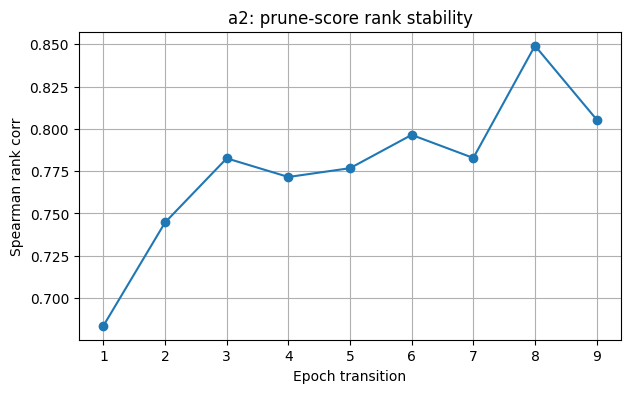

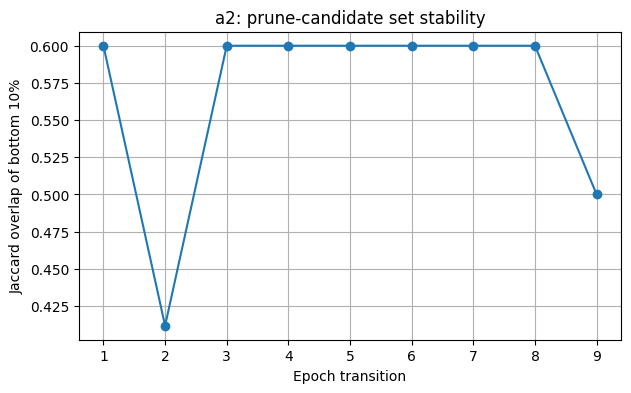

In [ ]:
plot_epoch_stability(history, layer="a2", ratio=0.10)

In [ ]:
def plot_sorted_utilization(stats, layer):
    """
    Plots sorted mean activation and sorted firing rate for one layer.

    layer: "a1" or "a2"
    """

    mean_activation = stats[f"{layer}_mean_activation"]
    firing_rate = stats[f"{layer}_firing_rate"]

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(mean_activation).values.numpy())
    plt.xlabel("Neuron rank")
    plt.ylabel("Mean activation")
    plt.title(f"{layer}: sorted mean activation")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(firing_rate).values.numpy())
    plt.xlabel("Neuron rank")
    plt.ylabel("Firing rate")
    plt.title(f"{layer}: sorted firing rate")
    plt.grid(True)
    plt.show()

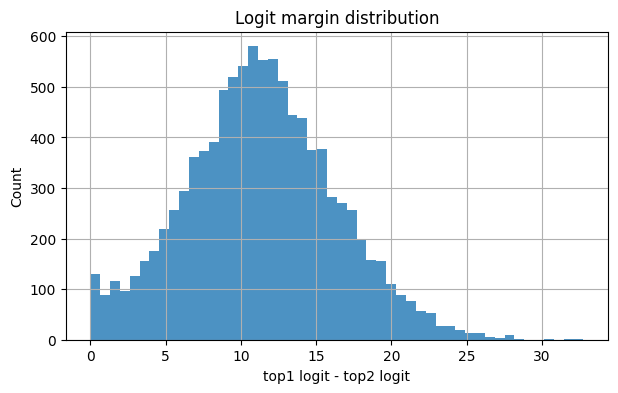

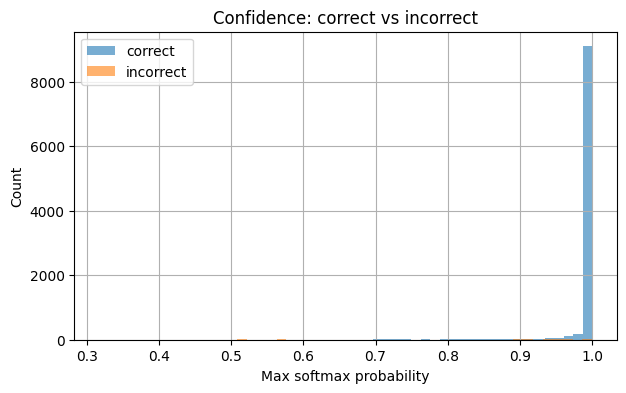

In [ ]:
plot_logit_diagnostics(last_val_stats)

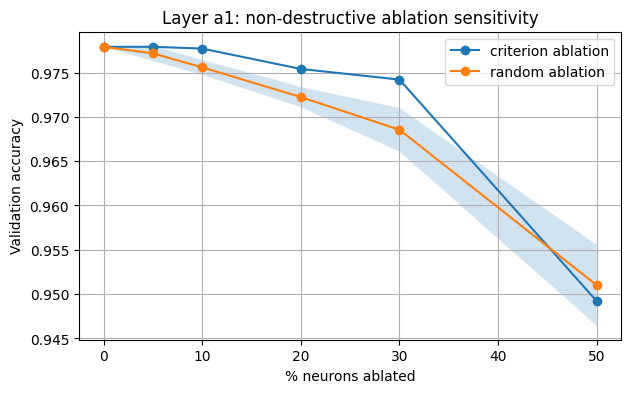

In [ ]:
a1_ablation = ablation_sensitivity_curve(
    model,
    val_loader,
    criterion,
    last_val_stats,
    layer="a1",
    ratios=(0.0, 0.05, 0.10, 0.20, 0.30, 0.50),
    random_trials=10,
)

plot_ablation_curve(
    a1_ablation,
    title="Layer a1: non-destructive ablation sensitivity",
)

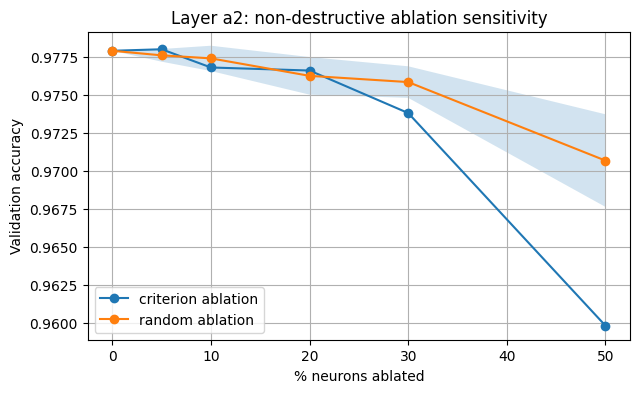

In [ ]:
a2_ablation = ablation_sensitivity_curve(
    model,
    val_loader,
    criterion,
    last_val_stats,
    layer="a2",
    ratios=(0.0, 0.05, 0.10, 0.20, 0.30, 0.50),
    random_trials=10,
)

plot_ablation_curve(
    a2_ablation,
    title="Layer a2: non-destructive ablation sensitivity",
)

In [ ]:
def show_prune_candidates(stats, layer, k=20):
    score = stats[f"{layer}_hebbian_prune_score"]
    mean_activation = stats[f"{layer}_mean_activation"]
    firing_rate = stats[f"{layer}_firing_rate"]
    outgoing_norm = stats[f"{layer}_outgoing_weight_norm"]
    redundancy = stats[f"{layer}_redundancy_max_abs_corr"]
    selectivity = stats[f"{layer}_class_selectivity"]

    ids = torch.argsort(score)[:k]

    print(f"Top {k} prune candidates for {layer}")
    print("-" * 80)
    print("id | score | mean_act | firing | out_norm | redundancy | class_selectivity")
    print("-" * 80)

    for idx in ids.tolist():
        print(
            f"{idx:3d} | "
            f"{score[idx]:.6f} | "
            f"{mean_activation[idx]:.6f} | "
            f"{firing_rate[idx]:.4f} | "
            f"{outgoing_norm[idx]:.4f} | "
            f"{redundancy[idx]:.4f} | "
            f"{selectivity[idx]:.4f}"
        )

In [ ]:
show_prune_candidates(last_val_stats, layer="a1", k=20)
show_prune_candidates(last_val_stats, layer="a2", k=20)

Top 20 prune candidates for a1
--------------------------------------------------------------------------------
id | score | mean_act | firing | out_norm | redundancy | class_selectivity
--------------------------------------------------------------------------------
246 | 0.000000 | 0.000000 | 0.0000 | 0.4346 | 0.0000 | 0.0000
 75 | 0.000000 | 0.000000 | 0.0000 | 0.4215 | 0.0000 | 0.0000
172 | 0.000000 | 0.000000 | 0.0000 | 0.4318 | 0.0000 | 0.0000
155 | 0.000000 | 0.000000 | 0.0000 | 0.4583 | 0.0000 | 0.0000
 60 | 0.000000 | 0.000000 | 0.0000 | 0.4321 | 0.0000 | 0.0000
108 | 0.000000 | 0.000000 | 0.0000 | 0.3766 | 0.0000 | 0.0000
112 | 0.000000 | 0.000000 | 0.0000 | 0.4371 | 0.0000 | 0.0000
204 | 0.000000 | 0.000000 | 0.0000 | 0.4361 | 0.0000 | 0.0000
126 | 0.000000 | 0.000000 | 0.0000 | 0.4133 | 0.0000 | 0.0000
 17 | 0.000000 | 0.000000 | 0.0000 | 0.4053 | 0.0000 | 0.0000
139 | 0.000000 | 0.000000 | 0.0000 | 0.4556 | 0.0000 | 0.0000
211 | 0.000000 | 0.000000 | 0.0000 | 0.3949 | 0.00

## plot_sorted_utilization and plot_class_selectivity ?

In [ ]:
def plot_sorted_utilization(stats, layer):
    """
    Plots sorted mean activation and sorted firing rate for one layer.

    layer: "a1" or "a2"
    """

    mean_activation = stats[f"{layer}_mean_activation"]
    firing_rate = stats[f"{layer}_firing_rate"]

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(mean_activation).values.numpy())
    plt.xlabel("Neuron rank")
    plt.ylabel("Mean activation")
    plt.title(f"{layer}: sorted mean activation")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(firing_rate).values.numpy())
    plt.xlabel("Neuron rank")
    plt.ylabel("Firing rate")
    plt.title(f"{layer}: sorted firing rate")
    plt.grid(True)
    plt.show()

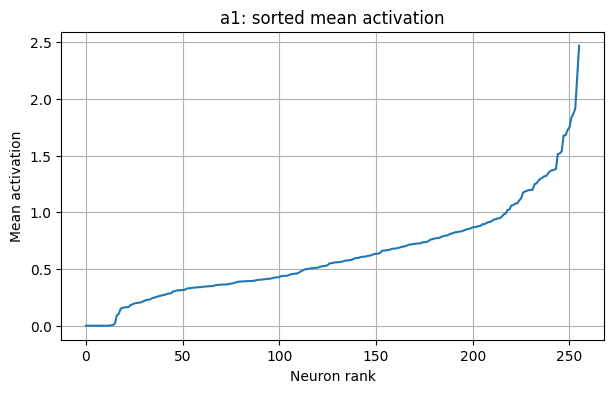

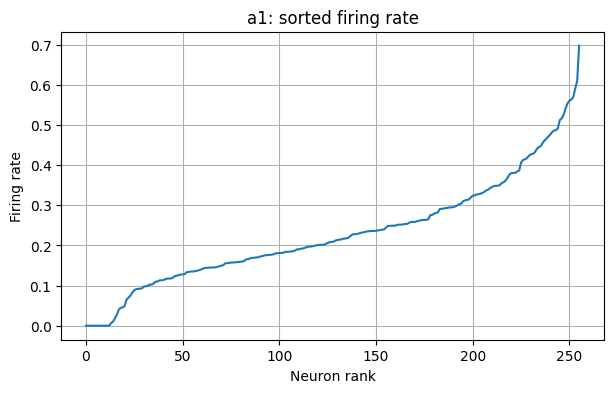

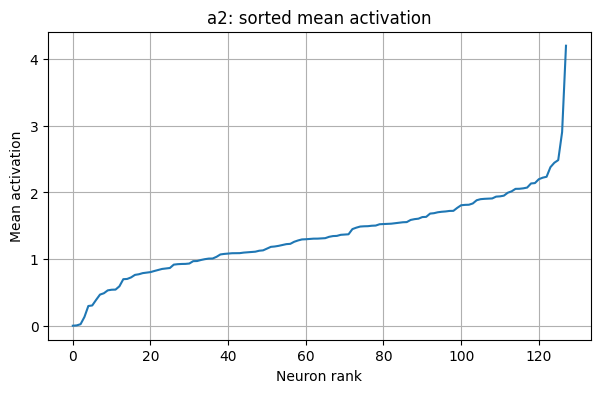

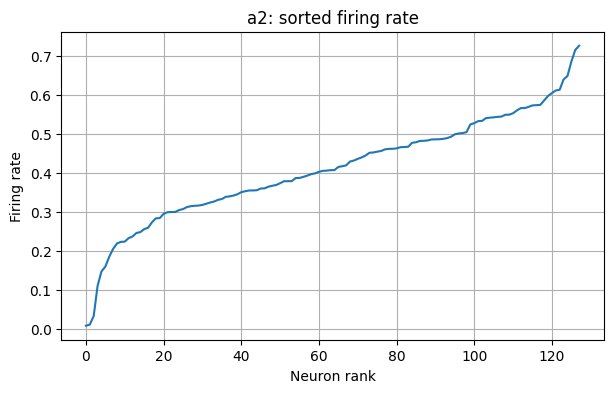

In [ ]:
last_val_stats = history["val_activation_stats"][-1]

plot_sorted_utilization(last_val_stats, layer="a1")
plot_sorted_utilization(last_val_stats, layer="a2")

In [ ]:
def plot_sorted_utilization_train_vs_val(train_stats, val_stats, layer):
    train_mean = train_stats[f"{layer}_mean_activation"]
    val_mean = val_stats[f"{layer}_mean_activation"]

    train_fire = train_stats[f"{layer}_firing_rate"]
    val_fire = val_stats[f"{layer}_firing_rate"]

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(train_mean).values.numpy(), label="train")
    plt.plot(torch.sort(val_mean).values.numpy(), label="val")
    plt.xlabel("Neuron rank")
    plt.ylabel("Mean activation")
    plt.title(f"{layer}: sorted mean activation — train vs val")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(train_fire).values.numpy(), label="train")
    plt.plot(torch.sort(val_fire).values.numpy(), label="val")
    plt.xlabel("Neuron rank")
    plt.ylabel("Firing rate")
    plt.title(f"{layer}: sorted firing rate — train vs val")
    plt.legend()
    plt.grid(True)
    plt.show()

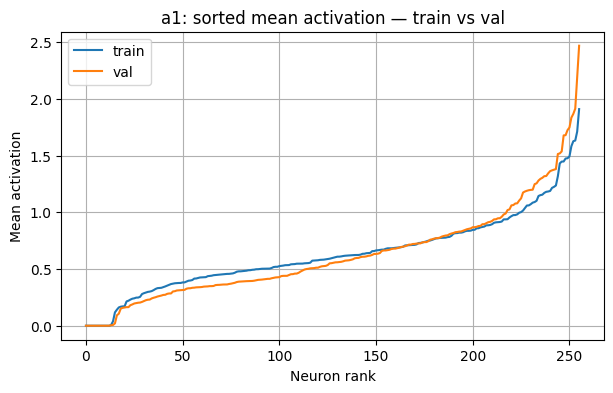

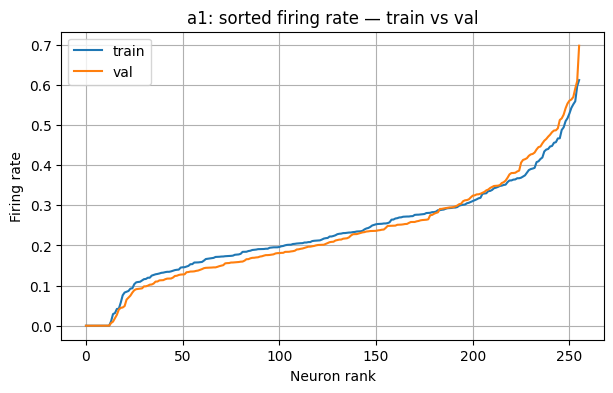

In [ ]:
plot_sorted_utilization_train_vs_val(
    history["train_activation_stats"][-1],
    history["val_activation_stats"][-1],
    layer="a1",
)

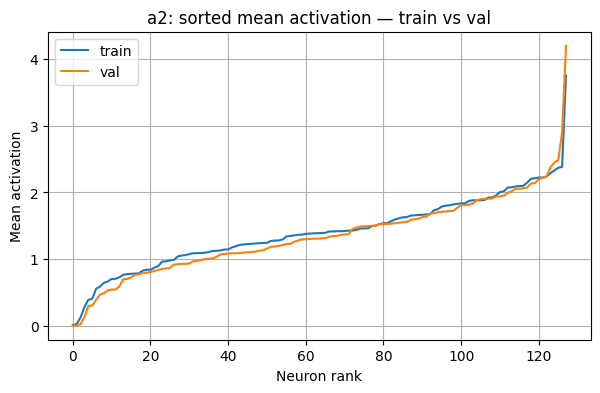

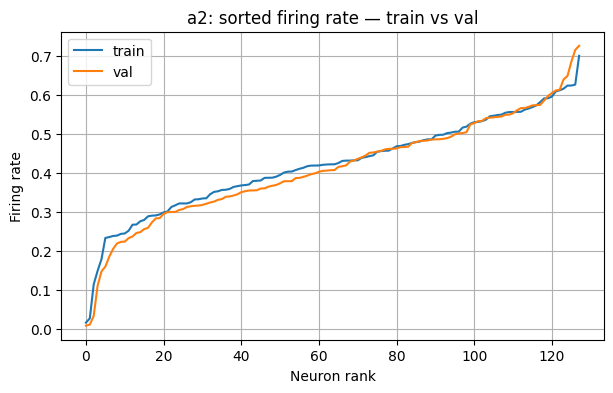

In [ ]:
plot_sorted_utilization_train_vs_val(
    history["train_activation_stats"][-1],
    history["val_activation_stats"][-1],
    layer="a2",
)

In [ ]:
def plot_class_selectivity(stats, layer):
    """
    Class selectivity:
        max_c P(neuron active | class=c)
        -
        mean_c P(neuron active | class=c)

    High value = neuron is class-specialized.
    """

    selectivity = stats[f"{layer}_class_selectivity"]

    plt.figure(figsize=(7, 4))
    plt.plot(torch.sort(selectivity).values.numpy())
    plt.xlabel("Neuron rank")
    plt.ylabel("Class selectivity")
    plt.title(f"{layer}: sorted class selectivity")
    plt.grid(True)
    plt.show()

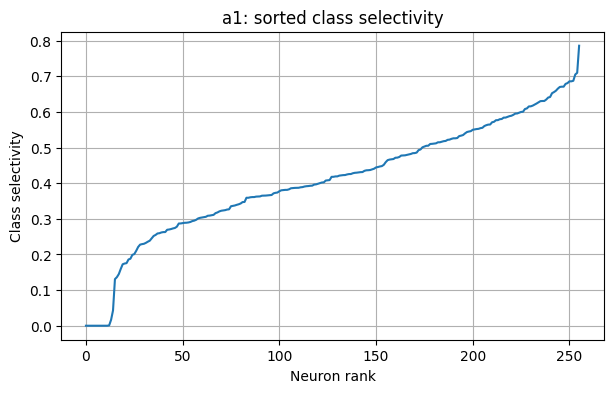

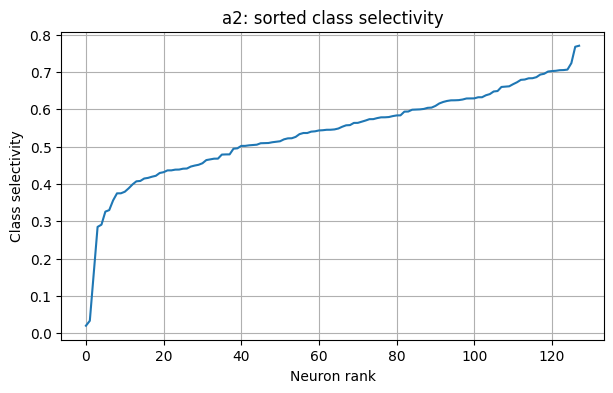

In [ ]:
plot_class_selectivity(last_val_stats, layer="a1")
plot_class_selectivity(last_val_stats, layer="a2")

In [ ]:
def plot_class_selectivity_with_candidates(stats, layer, k=20):
    selectivity = stats[f"{layer}_class_selectivity"]
    prune_score = stats[f"{layer}_hebbian_prune_score"]

    candidate_ids = torch.argsort(prune_score)[:k]

    plt.figure(figsize=(7, 4))
    plt.plot(selectivity.numpy(), label="class selectivity")

    plt.scatter(
        candidate_ids.numpy(),
        selectivity[candidate_ids].numpy(),
        s=50,
        label=f"top {k} prune candidates",
    )

    plt.xlabel("Neuron index")
    plt.ylabel("Class selectivity")
    plt.title(f"{layer}: class selectivity with prune candidates")
    plt.legend()
    plt.grid(True)
    plt.show()

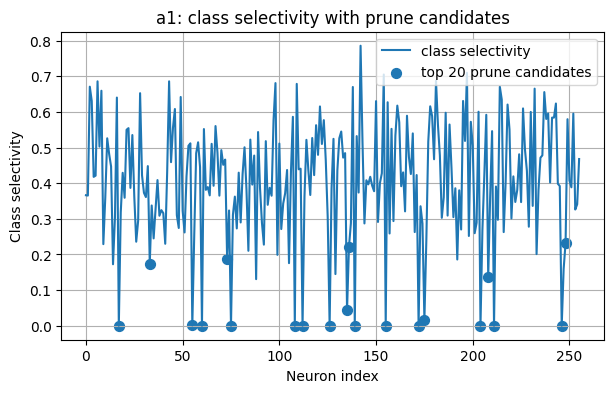

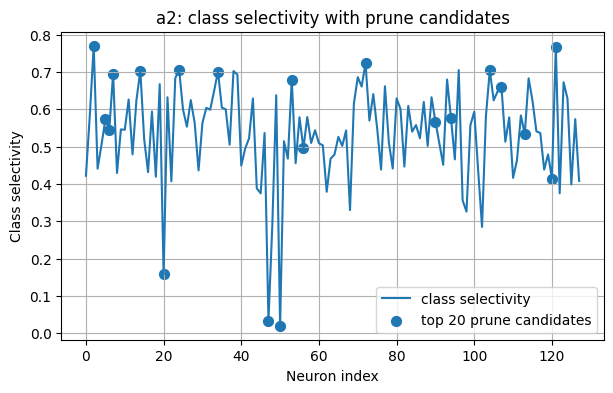

In [ ]:
plot_class_selectivity_with_candidates(last_val_stats, layer="a1", k=20)
plot_class_selectivity_with_candidates(last_val_stats, layer="a2", k=20)

# Predecessor papers
https://www.pnas.org/doi/abs/10.1073/pnas.2121331119

https://ieeexplore.ieee.org/abstract/document/10650478

https://journals.aps.org/pre/abstract/10.1103/PhysRevE.62.8387

https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1009458

https://link.springer.com/chapter/10.1007/978-3-032-11352-8_5


## Scratch notes

- debug and solve storage failure
- debug and solve timeouts bottlenecks
- cadrage

Steeve : 

+ Extend benchmarking : numerical / textual . 
+ TMLR 

CFA: 
+ Bayesian neural networks
    + distr instead of collapsed scalar (eg mean)
        + cost of stat collection ?? (eg kl)

Is: latest update


+ Check with Fisher information (FI ) (potentially KL).
+ What about applying epiplexity ? only if worth it.
+ Check with deeper mlp (diff datasets/benchmarks).


# FI to loss criterion

## Structured pruning protocol

The full experiment pipeline lives in `structured_pruning_protocol.py` to keep this notebook as the control surface. The run cell is guarded by `RUN_EXPERIMENTS = False` so opening or restarting the notebook does not start the full grid accidentally.

Important defaults:

- `weight_fisher_mode="batch"` is a batch-gradient diagonal approximation; set `"per_sample"` for a slower empirical Fisher estimate.
- `single_neuron_ablation` is not included in the default full grid because it is intentionally expensive. Add it to `criteria` for reference-only runs.
- Masked evaluation is used for pruning correctness; compact materialized MLPs are also evaluated for realistic parameter/MAC and inference-time comparisons.

In [7]:
from pathlib import Path
import sys

candidate_module_dirs = [
    Path.cwd(),
    Path.cwd() / "mlphebiancorr" / "exp",
    Path.cwd().parent / "exp",
]

for module_dir in candidate_module_dirs:
    if (module_dir / "structured_pruning_protocol.py").exists():
        sys.path.insert(0, str(module_dir))
        break

from structured_pruning_protocol import (
    ProtocolConfig,
    read_csv_rows,
    run_protocol,
    plot_accuracy_vs_pruning,
    plot_accuracy_drop_vs_pruning,
    plot_improvement_over_random,
    plot_layer_sensitivity_heatmap,
    plot_ranking_stability,
    plot_criteria_correlation_matrix,
    plot_cost_benefit_pareto,
    plot_finetune_recovery,
    plot_score_distribution,
    plot_fisher_vs_lossfree_scatter,
    plot_auc_damage_summary,
    plot_failure_cases,
    plot_fisher_advantage,
    plot_parameter_reduction_vs_speedup,
)


In [8]:
SMOKE_CONFIG = ProtocolConfig(
    dataset_names=("MNIST",),
    architectures=("small",),
    seeds=(42,),
    epochs=1,
    val_size=2_000,
    calibration_size=512,
    batch_size=128,
    pruning_percentages=(0.05, 0.10, 0.20),
    fine_tune_epochs=(0,),
    criteria=(
        "random",
        "output_weight_norm",
        "mean_activation",
        "firing_rate",
        "activation_variance",
        "class_selectivity",
        "redundancy",
        "hebbian",
        "activation_fisher",
        "weight_fisher",
    ),
    random_trials=2,
    prune_scopes=("all", "layerwise"),
    run_root="runs/structured_pruning_smoke",
    data_root="data",
    num_workers=2,
)

FULL_PROTOCOL_CONFIG = ProtocolConfig(
    dataset_names=("MNIST", "FashionMNIST", "KMNIST"),
    architectures=("small", "medium", "deep"),
    seeds=(42, 43, 44),
    epochs=10,
    val_size=10_000,
    calibration_size=2_048,
    pruning_percentages=(0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70),
    fine_tune_epochs=(0, 1, 3, 5),
    criteria=SMOKE_CONFIG.criteria,
    random_trials=5,
    prune_scopes=("all", "layerwise"),
    calibration_sensitivity_sizes=(128, 256, 512, 1024),
    run_root="runs/structured_pruning_full",
    data_root="data",
    num_workers=2,
)

CIFAR_FLAT_CONFIG = ProtocolConfig(
    dataset_names=("CIFAR10",),
    architectures=("cifar_flat",),
    seeds=(42, 43, 44),
    epochs=10,
    val_size=5_000,
    calibration_size=2_048,
    criteria=SMOKE_CONFIG.criteria,
    run_root="runs/structured_pruning_cifar_flat",
    data_root="data",
    num_workers=2,
)


In [9]:
RUN_EXPERIMENTS = True
ACTIVE_CONFIG = FULL_PROTOCOL_CONFIG


if RUN_EXPERIMENTS:
    structured_results = run_protocol(ACTIVE_CONFIG)
else:
    print("Set RUN_EXPERIMENTS = True and choose ACTIVE_CONFIG to execute the protocol.")


run_protocol: start dataset=MNIST architecture=small seed=42
MNIST/small/seed=42 epoch 001: train_acc=0.8946 val_acc=0.9495 test_acc=0.9563 time=2.9s
MNIST/small/seed=42 epoch 002: train_acc=0.9543 val_acc=0.9617 test_acc=0.9636 time=2.3s
MNIST/small/seed=42 epoch 003: train_acc=0.9658 val_acc=0.9680 test_acc=0.9702 time=2.5s
MNIST/small/seed=42 epoch 004: train_acc=0.9722 val_acc=0.9710 test_acc=0.9731 time=2.6s
MNIST/small/seed=42 epoch 005: train_acc=0.9767 val_acc=0.9741 test_acc=0.9743 time=2.5s
MNIST/small/seed=42 epoch 006: train_acc=0.9792 val_acc=0.9744 test_acc=0.9789 time=2.6s
MNIST/small/seed=42 epoch 007: train_acc=0.9821 val_acc=0.9774 test_acc=0.9776 time=2.6s
MNIST/small/seed=42 epoch 008: train_acc=0.9835 val_acc=0.9761 test_acc=0.9788 time=2.5s
MNIST/small/seed=42 epoch 009: train_acc=0.9833 val_acc=0.9780 test_acc=0.9787 time=2.5s
MNIST/small/seed=42 epoch 010: train_acc=0.9862 val_acc=0.9780 test_acc=0.9807 time=2.5s
MNIST/small/seed=42: scoring epoch 010 start
  sc

0.1%

100.0%


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%


...

100.0%

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



FashionMNIST/small/seed=42 epoch 001: train_acc=0.8022 val_acc=0.8498 test_acc=0.8408 time=2.8s
FashionMNIST/small/seed=42 epoch 002: train_acc=0.8568 val_acc=0.8609 test_acc=0.8526 time=2.5s
FashionMNIST/small/seed=42 epoch 003: train_acc=0.8703 val_acc=0.8762 test_acc=0.8690 time=2.7s
FashionMNIST/small/seed=42 epoch 004: train_acc=0.8774 val_acc=0.8762 test_acc=0.8664 time=2.6s
FashionMNIST/small/seed=42 epoch 005: train_acc=0.8851 val_acc=0.8835 test_acc=0.8772 time=2.3s
FashionMNIST/small/seed=42 epoch 006: train_acc=0.8872 val_acc=0.8838 test_acc=0.8766 time=2.5s
FashionMNIST/small/seed=42 epoch 007: train_acc=0.8907 val_acc=0.8878 test_acc=0.8765 time=2.6s
FashionMNIST/small/seed=42 epoch 008: train_acc=0.8944 val_acc=0.8833 test_acc=0.8748 time=2.6s
FashionMNIST/small/seed=42 epoch 009: train_acc=0.8970 val_acc=0.8889 test_acc=0.8819 time=2.6s
FashionMNIST/small/seed=42 epoch 010: train_acc=0.9009 val_acc=0.8900 test_acc=0.8782 time=2.7s
FashionMNIST/small/seed=42: scoring epoc

Exception in thread Thread-109 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1073, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1010, in run
    self._target(*self._args, **self._kwargs)
  File "/home/ismail/Desktop/old_d_o/misc/misc/hebiancorr/mlphebiancorr/venv_hebian/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/home/ismail/Desktop/old_d_o/misc/misc/hebiancorr/mlphebiancorr/venv_hebian/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ismail/Desktop/old_d_o/misc/misc/hebiancorr/mlphebiancorr/venv_hebia

KeyboardInterrupt: 

In [18]:
RESULT_ROOT = Path(ACTIVE_CONFIG.run_root)

def load_optional_csv(filename):
    path = RESULT_ROOT / filename
    if path.exists():
        rows = read_csv_rows(path)
        print(f"Loaded {len(rows)} rows from {path}")
        return rows
    print(f"Missing optional result file: {path}")
    return []

pruning_rows = load_optional_csv("pruning_results_all.csv")
score_rows = load_optional_csv("score_values_all.csv")
stability_rows = load_optional_csv("ranking_stability_all.csv")
rank_agreement_rows = load_optional_csv("rank_agreement_all.csv")
calibration_sensitivity_rows = load_optional_csv("calibration_sensitivity_all.csv")


Missing optional result file: runs/structured_pruning_full/pruning_results_all.csv
Missing optional result file: runs/structured_pruning_full/score_values_all.csv
Missing optional result file: runs/structured_pruning_full/ranking_stability_all.csv
Missing optional result file: runs/structured_pruning_full/rank_agreement_all.csv
Missing optional result file: runs/structured_pruning_full/calibration_sensitivity_all.csv


In [16]:
# Example plots after a run. Adjust dataset/architecture/epoch/layer as needed.
if pruning_rows:
    plot_accuracy_vs_pruning(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_accuracy_drop_vs_pruning(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_improvement_over_random(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_layer_sensitivity_heatmap(pruning_rows, dataset="MNIST", architecture="small", criterion="hebbian", fine_tune_epochs=0)
    plot_cost_benefit_pareto(pruning_rows, dataset="MNIST", architecture="small", pruning_percentage=0.20, fine_tune_epochs=0)
    plot_finetune_recovery(pruning_rows, dataset="MNIST", architecture="small", criterion="hebbian", pruning_percentage=0.20)
    plot_auc_damage_summary(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_failure_cases(pruning_rows, dataset="MNIST", architecture="small", fine_tune_epochs=0)
    plot_fisher_advantage(pruning_rows, dataset="MNIST", architecture="small", lossfree_criterion="hebbian")
    plot_parameter_reduction_vs_speedup(pruning_rows, dataset="MNIST", architecture="small", fine_tune_epochs=0)

if score_rows:
    plot_score_distribution(score_rows, dataset="MNIST", architecture="small", epoch=1, layer="a1")
    plot_fisher_vs_lossfree_scatter(score_rows, dataset="MNIST", architecture="small", epoch=1, layer="a1")
    plot_criteria_correlation_matrix(score_rows, dataset="MNIST", architecture="small", layer="a1", epoch=1)

if stability_rows:
    plot_ranking_stability(stability_rows, criterion="hebbian", layer="a1")


### interrupted exp results

In [19]:
RESULT_ROOT = Path("runs/structured_pruning_full")

def load_many(pattern):
    rows = []
    for path in sorted(RESULT_ROOT.glob(pattern)):
        part = read_csv_rows(path)
        print(f"Loaded {len(part)} rows from {path}")
        rows.extend(part)
    return rows

pruning_rows = load_many("MNIST/*/seed_*/pruning_results.csv")
score_rows = load_many("MNIST/*/seed_*/score_values.csv")
stability_rows = load_many("MNIST/*/seed_*/ranking_stability.csv")
rank_agreement_rows = load_many("MNIST/*/seed_*/rank_agreement.csv")
calibration_sensitivity_rows = load_many("MNIST/*/seed_*/calibration_sensitivity.csv")

len(pruning_rows), len(score_rows)

Loaded 2744 rows from runs/structured_pruning_full/MNIST/deep/seed_42/pruning_results.csv
Loaded 2744 rows from runs/structured_pruning_full/MNIST/deep/seed_43/pruning_results.csv
Loaded 2744 rows from runs/structured_pruning_full/MNIST/deep/seed_44/pruning_results.csv
Loaded 1960 rows from runs/structured_pruning_full/MNIST/medium/seed_42/pruning_results.csv
Loaded 1960 rows from runs/structured_pruning_full/MNIST/medium/seed_43/pruning_results.csv
Loaded 1960 rows from runs/structured_pruning_full/MNIST/medium/seed_44/pruning_results.csv
Loaded 1176 rows from runs/structured_pruning_full/MNIST/small/seed_42/pruning_results.csv
Loaded 1176 rows from runs/structured_pruning_full/MNIST/small/seed_43/pruning_results.csv
Loaded 1176 rows from runs/structured_pruning_full/MNIST/small/seed_44/pruning_results.csv
Loaded 15552 rows from runs/structured_pruning_full/MNIST/deep/seed_42/score_values.csv
Loaded 15552 rows from runs/structured_pruning_full/MNIST/deep/seed_43/score_values.csv
Loade

(17640, 82944)

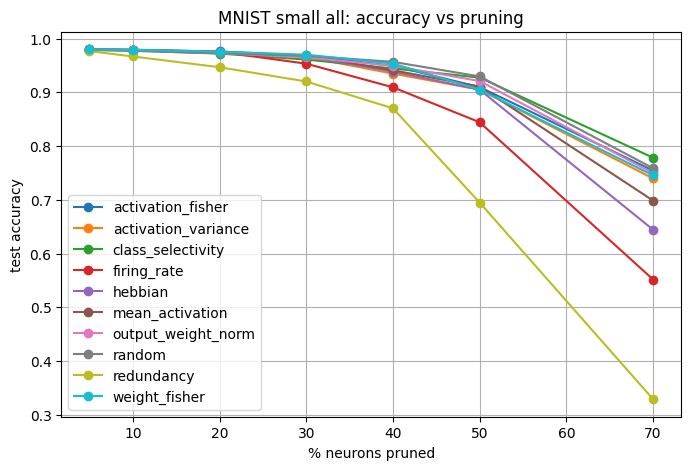

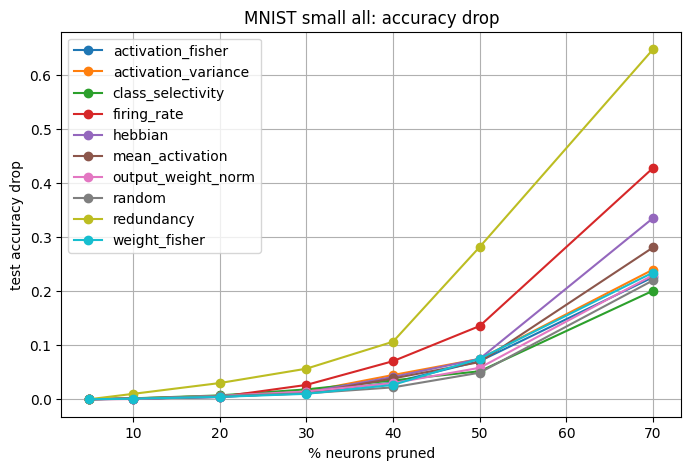

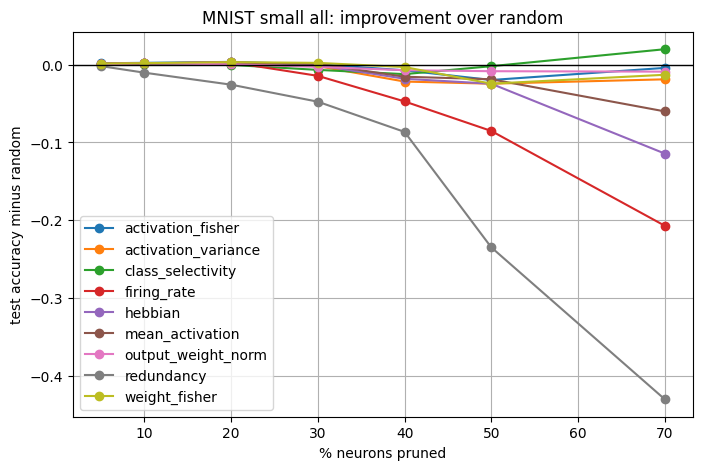

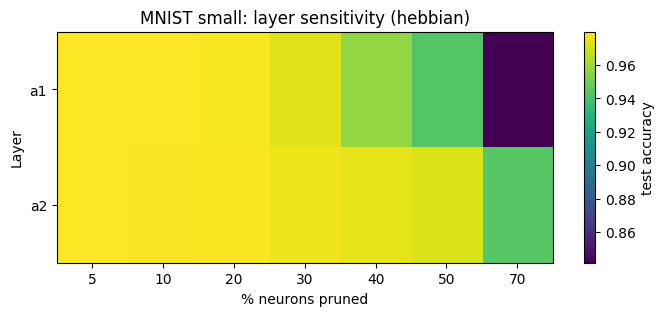

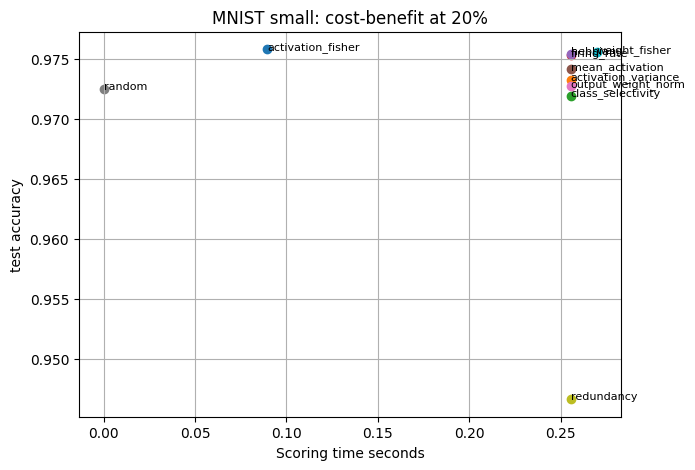

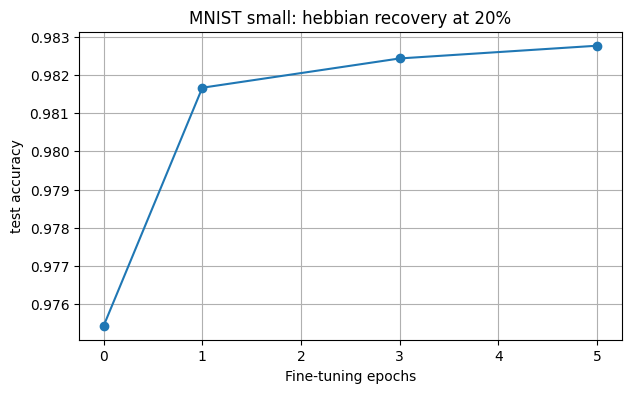

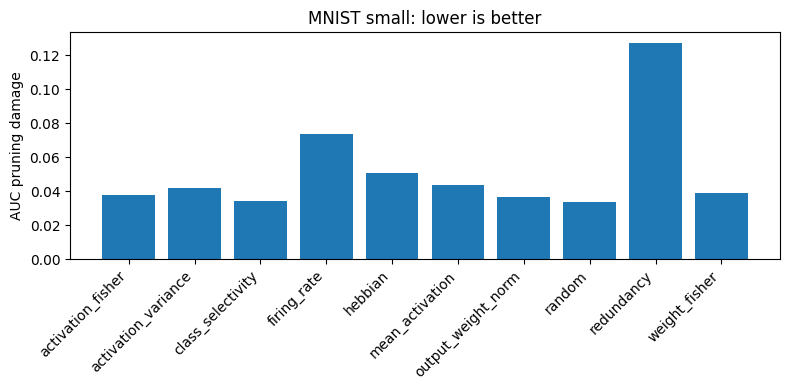

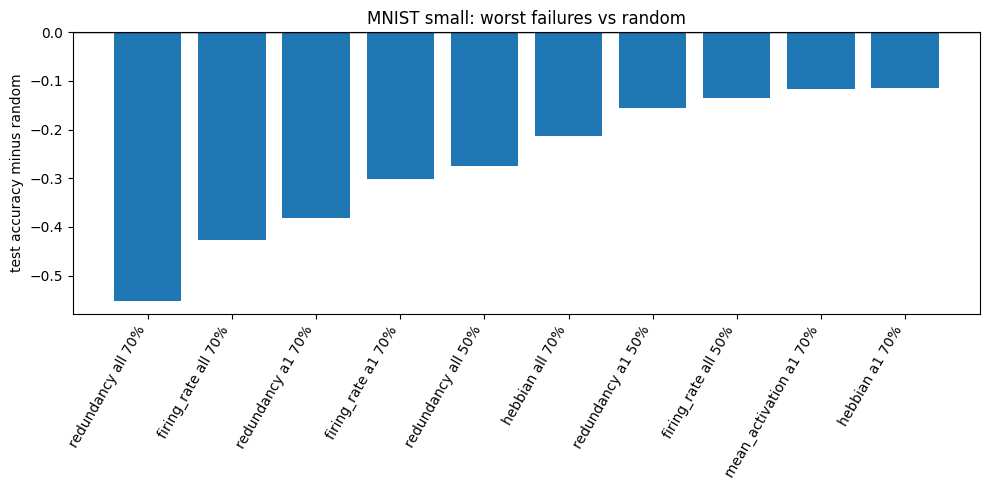

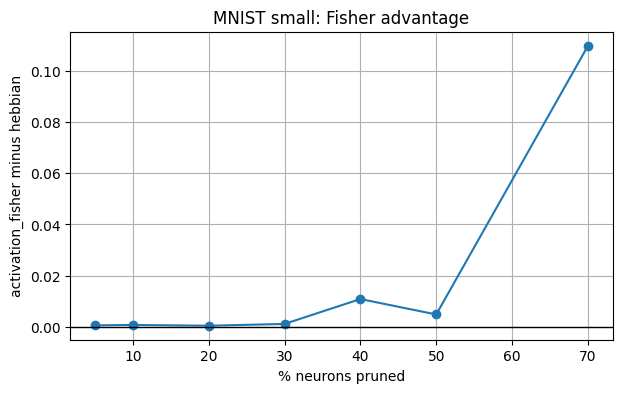

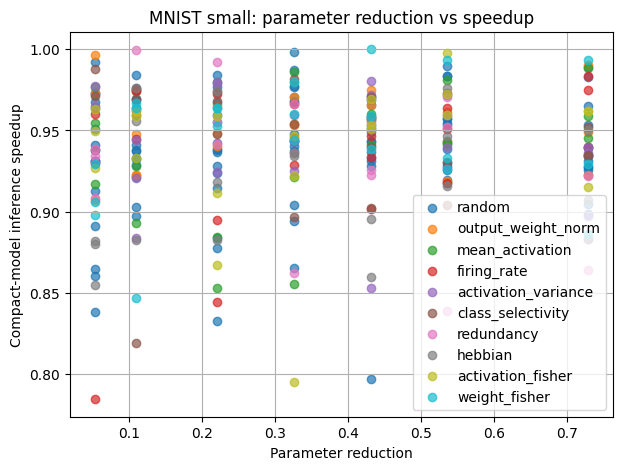

/home/ismail/Desktop/old_d_o/misc/misc/hebiancorr/mlphebiancorr/exp/structured_pruning_protocol.py:2466: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


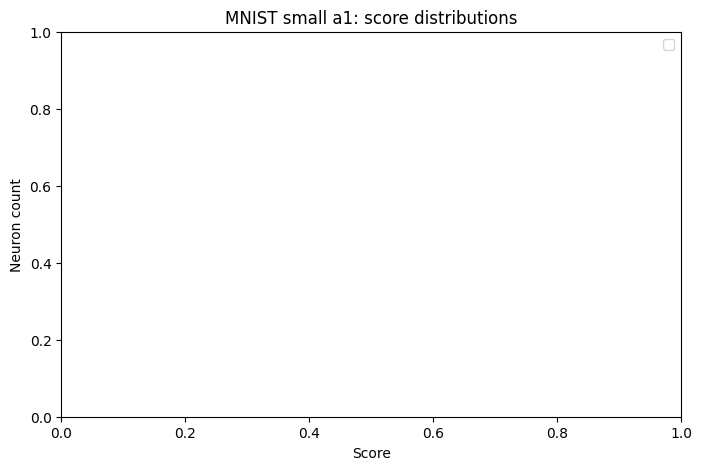

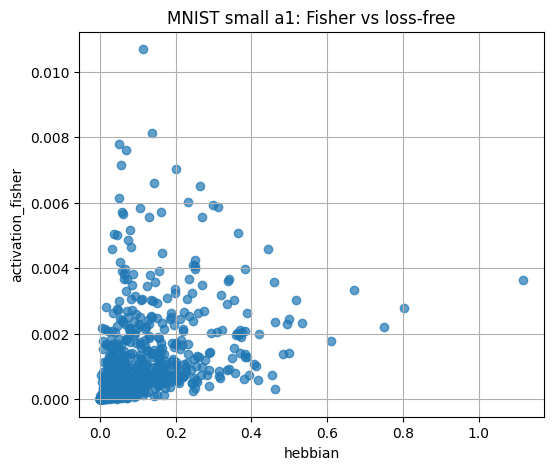

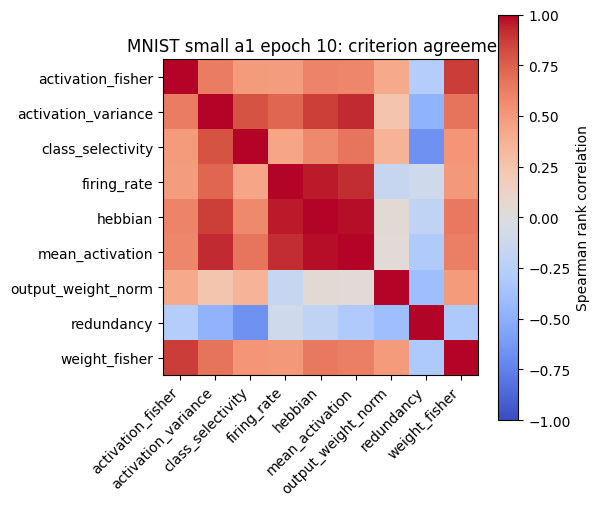

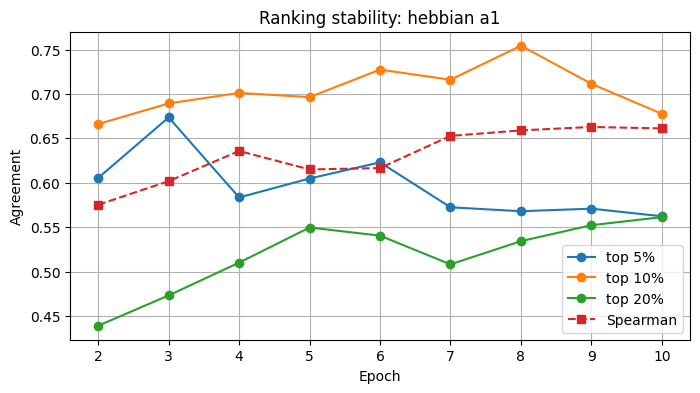

In [23]:
# Example plots after a run. Adjust dataset/architecture/epoch/layer as needed.
if pruning_rows:
    plot_accuracy_vs_pruning(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_accuracy_drop_vs_pruning(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_improvement_over_random(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_layer_sensitivity_heatmap(pruning_rows, dataset="MNIST", architecture="small", criterion="hebbian", fine_tune_epochs=0)
    plot_cost_benefit_pareto(pruning_rows, dataset="MNIST", architecture="small", pruning_percentage=0.20, fine_tune_epochs=0)
    plot_finetune_recovery(pruning_rows, dataset="MNIST", architecture="small", criterion="hebbian", pruning_percentage=0.20)
    plot_auc_damage_summary(pruning_rows, dataset="MNIST", architecture="small", layer="all", fine_tune_epochs=0)
    plot_failure_cases(pruning_rows, dataset="MNIST", architecture="small", fine_tune_epochs=0)
    plot_fisher_advantage(pruning_rows, dataset="MNIST", architecture="small", lossfree_criterion="hebbian")
    plot_parameter_reduction_vs_speedup(pruning_rows, dataset="MNIST", architecture="small", fine_tune_epochs=0)

if score_rows:
    plot_score_distribution(score_rows, dataset="MNIST", architecture="small", epoch=1, layer="a1")
    plot_fisher_vs_lossfree_scatter(score_rows, dataset="MNIST", architecture="small", epoch=10, layer="a1")
    plot_criteria_correlation_matrix(score_rows, dataset="MNIST", architecture="small", layer="a1", epoch=10)

if stability_rows:
    plot_ranking_stability(stability_rows, criterion="hebbian", layer="a1")


### DEEP

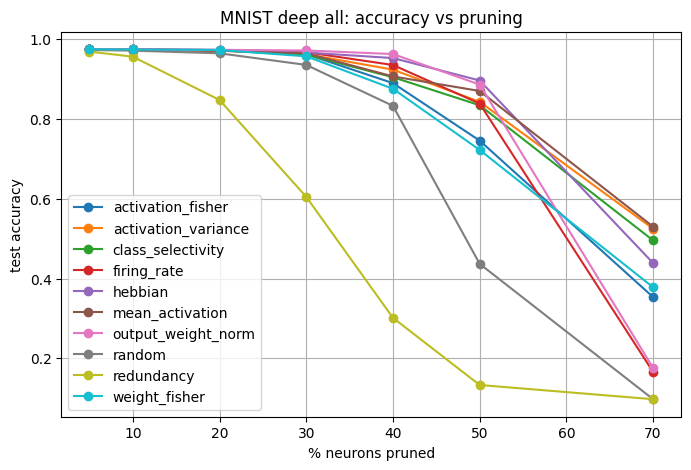

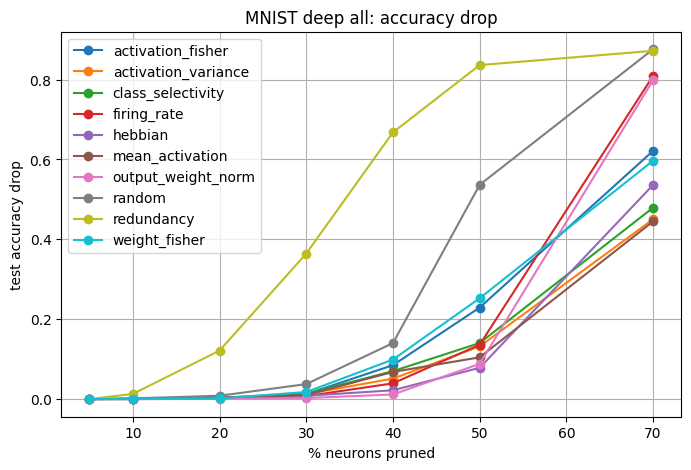

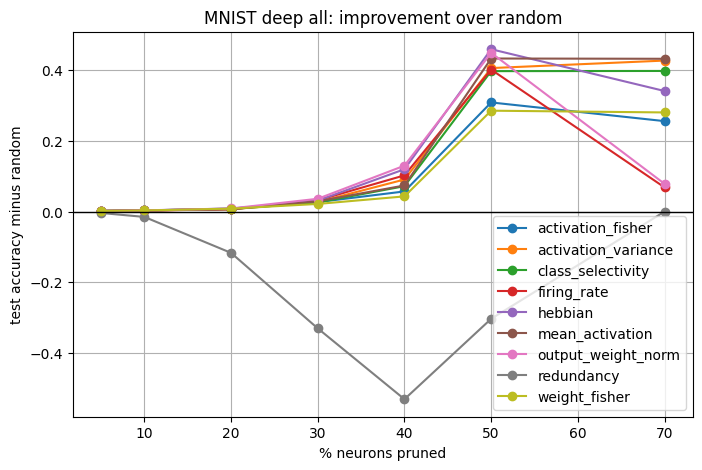

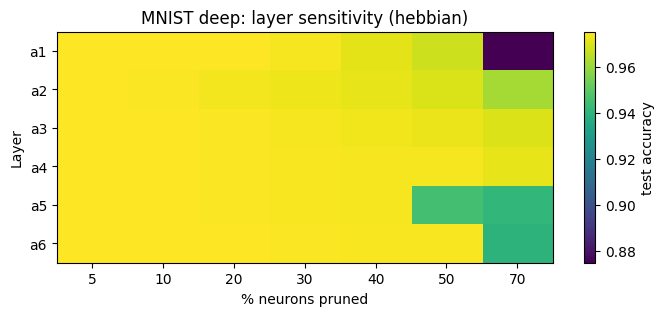

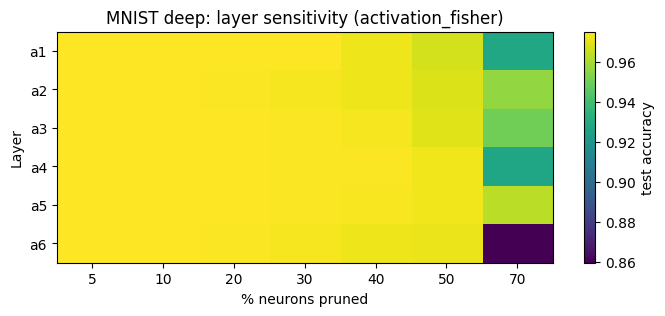

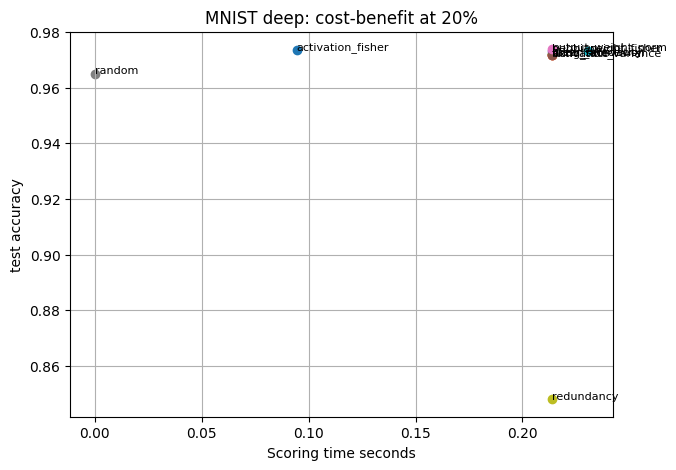

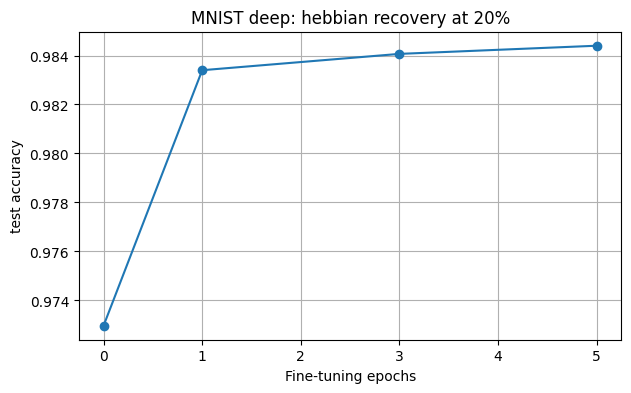

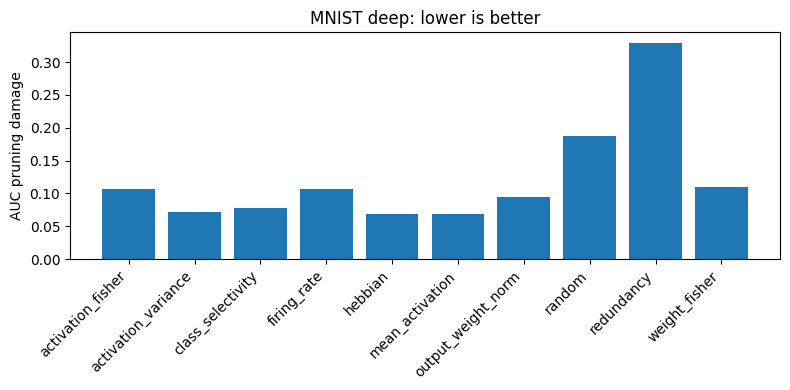

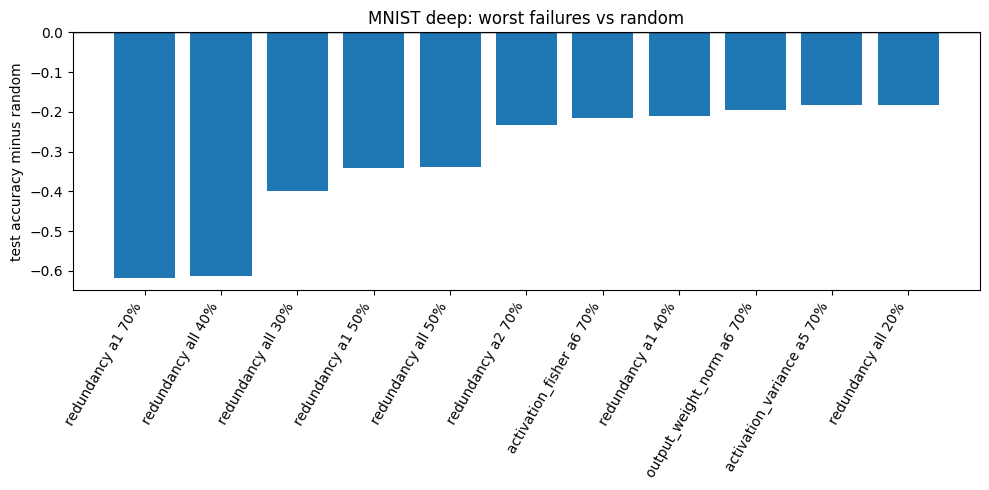

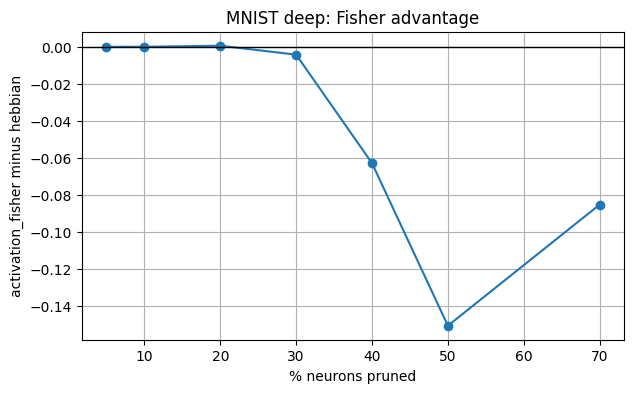

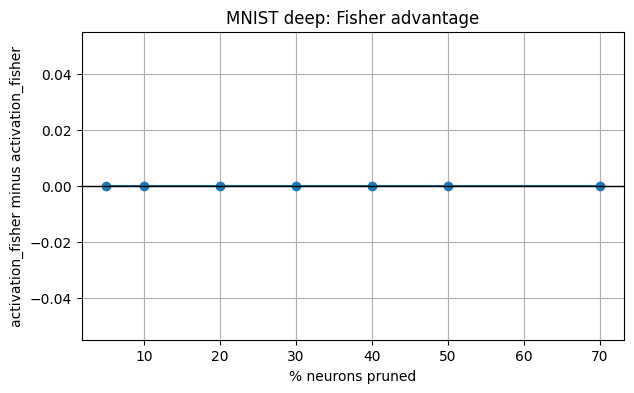

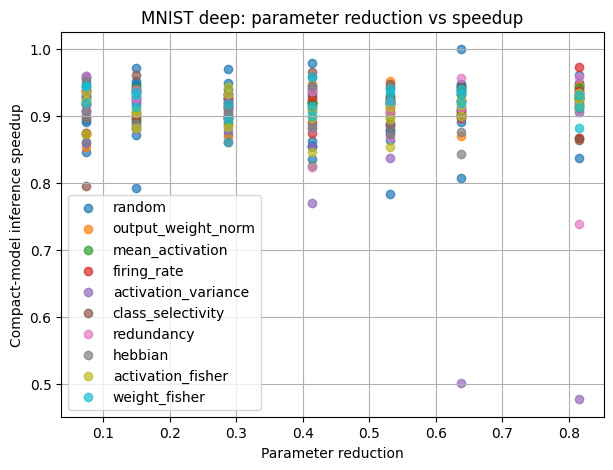

/home/ismail/Desktop/old_d_o/misc/misc/hebiancorr/mlphebiancorr/exp/structured_pruning_protocol.py:2466: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


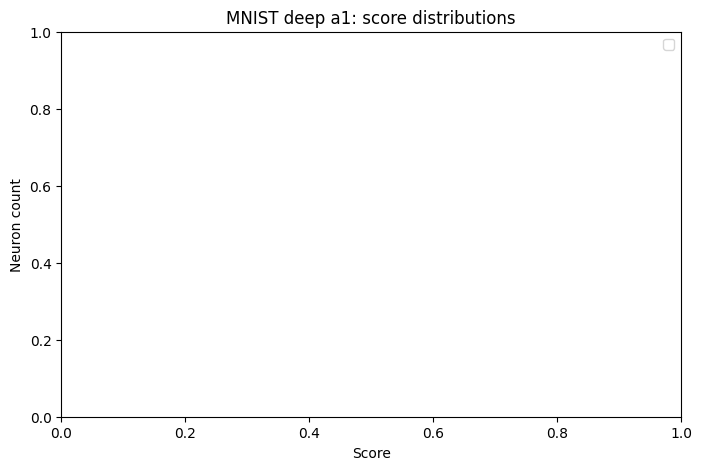

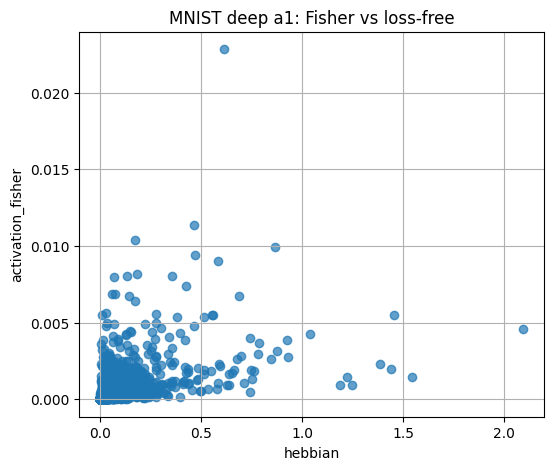

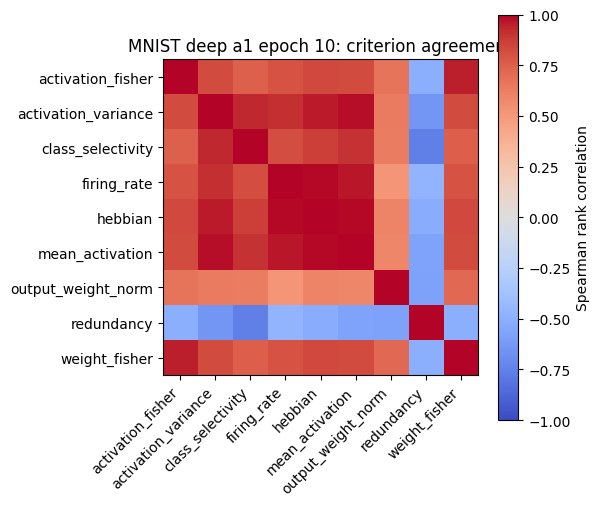

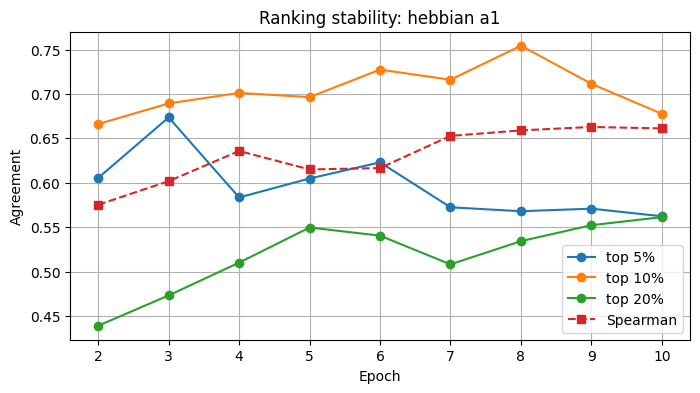

In [26]:
# Example plots after a run. Adjust dataset/architecture/epoch/layer as needed.
if pruning_rows:
    plot_accuracy_vs_pruning(pruning_rows, dataset="MNIST", architecture="deep", layer="all", fine_tune_epochs=0)
    plot_accuracy_drop_vs_pruning(pruning_rows, dataset="MNIST", architecture="deep", layer="all", fine_tune_epochs=0)
    plot_improvement_over_random(pruning_rows, dataset="MNIST", architecture="deep", layer="all", fine_tune_epochs=0)
    plot_layer_sensitivity_heatmap(pruning_rows, dataset="MNIST", architecture="deep", criterion="hebbian", fine_tune_epochs=0)
    plot_layer_sensitivity_heatmap(pruning_rows, dataset="MNIST", architecture="deep", criterion="activation_fisher", fine_tune_epochs=0)

    plot_cost_benefit_pareto(pruning_rows, dataset="MNIST", architecture="deep", pruning_percentage=0.20, fine_tune_epochs=0)
    plot_finetune_recovery(pruning_rows, dataset="MNIST", architecture="deep", criterion="hebbian", pruning_percentage=0.20)
    plot_auc_damage_summary(pruning_rows, dataset="MNIST", architecture="deep", layer="all", fine_tune_epochs=0)
    plot_failure_cases(pruning_rows, dataset="MNIST", architecture="deep", fine_tune_epochs=0)
    plot_fisher_advantage(pruning_rows, dataset="MNIST", architecture="deep", lossfree_criterion="hebbian")
    plot_fisher_advantage(pruning_rows, dataset="MNIST", architecture="deep", lossfree_criterion="activation_fisher")

    plot_parameter_reduction_vs_speedup(pruning_rows, dataset="MNIST", architecture="deep", fine_tune_epochs=0)

if score_rows:
    plot_score_distribution(score_rows, dataset="MNIST", architecture="deep", epoch=1, layer="a1")
    plot_fisher_vs_lossfree_scatter(score_rows, dataset="MNIST", architecture="deep", epoch=10, layer="a1")
    plot_criteria_correlation_matrix(score_rows, dataset="MNIST", architecture="deep", layer="a1", epoch=10)

if stability_rows:
    plot_ranking_stability(stability_rows, criterion="hebbian", layer="a1")


### Optional expensive reference

To run non-destructive single-neuron ablation as an empirical reference, add `"single_neuron_ablation"` to `criteria` for a small dataset/model first. It performs one validation pass per hidden neuron and should not be mixed into a large full-grid run without budgeting time.